# Volve Oil Production Data Science Project
## Notebook 04: Operational Production Insights and Decision Support

### Purpose

This notebook turns the analytical and forecasting results from Notebooks 00–03 into producer-well monitoring outputs that can later be used in the application.

The analysis focuses on the five core producer wells and combines recent production behaviour with the final forecasting results. It examines current production condition, recent changes, fluid-ratio availability, well-level forecast reliability, and cases where Ridge Regression produced physically implausible predictions.

Production condition and forecasting performance are treated as separate sources of information. The notebook does not introduce new model training, engineering alarm thresholds, or automated field recommendations.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


PROJECT_ROOT = Path(
    r"F:\DataScience_Projects\Volve_Oil_Production"
)

PROCESSED_DATA_DIR = (
    PROJECT_ROOT
    / "data"
    / "processed"
)

MODEL_OUTPUT_DIR = (
    PROJECT_ROOT
    / "outputs"
    / "03_model_development"
)

NOTEBOOK04_OUTPUT_DIR = (
    PROJECT_ROOT
    / "outputs"
    / "04_operational_insights"
)

NOTEBOOK04_OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)


print(
    "Notebook 04 output directory:",
    NOTEBOOK04_OUTPUT_DIR
)

Notebook 04 output directory: F:\DataScience_Projects\Volve_Oil_Production\outputs\04_operational_insights


In [2]:
MODELING_READY_PATH = (
    PROCESSED_DATA_DIR
    / "02_modeling_ready_monthly_forecast.csv"
)

FINAL_HOLDOUT_PREDICTIONS_PATH = (
    MODEL_OUTPUT_DIR
    / "final_holdout_predictions.csv"
)

FINAL_HOLDOUT_WELL_METRICS_PATH = (
    MODEL_OUTPUT_DIR
    / "final_holdout_well_metrics.csv"
)

FINAL_HOLDOUT_POOLED_METRICS_PATH = (
    MODEL_OUTPUT_DIR
    / "final_holdout_pooled_metrics.csv"
)

GENERALIZATION_PATH = (
    MODEL_OUTPUT_DIR
    / "ridge_vs_persistence_generalization.csv"
)


required_input_paths = [
    MODELING_READY_PATH,
    FINAL_HOLDOUT_PREDICTIONS_PATH,
    FINAL_HOLDOUT_WELL_METRICS_PATH,
    FINAL_HOLDOUT_POOLED_METRICS_PATH,
    GENERALIZATION_PATH
]


for path in required_input_paths:

    print(
        path.name,
        "->",
        path.exists()
    )

02_modeling_ready_monthly_forecast.csv -> True
final_holdout_predictions.csv -> True
final_holdout_well_metrics.csv -> True
final_holdout_pooled_metrics.csv -> True
ridge_vs_persistence_generalization.csv -> True


## 1. Frozen Analytical Inputs and Well-Level Monitoring Base

The operational analysis begins by loading the frozen modelling-ready dataset and final evaluation outputs produced in Notebooks 02 and 03.

No model is retrained in this notebook.

The purpose of this section is to verify the available producer-well histories and construct a clean monitoring base that can support later well-status, decline, forecasting, and decision-support analyses.

In [3]:
modeling_ready_df = pd.read_csv(
    MODELING_READY_PATH,
    parse_dates=["DATE"]
)

final_holdout_predictions_df = pd.read_csv(
    FINAL_HOLDOUT_PREDICTIONS_PATH,
    parse_dates=["DATE"]
)

final_holdout_well_metrics_df = pd.read_csv(
    FINAL_HOLDOUT_WELL_METRICS_PATH
)

final_holdout_pooled_metrics_df = pd.read_csv(
    FINAL_HOLDOUT_POOLED_METRICS_PATH
)

generalization_df = pd.read_csv(
    GENERALIZATION_PATH
)


print(
    "Model-ready rows:",
    len(modeling_ready_df)
)

print(
    "Final holdout prediction rows:",
    len(final_holdout_predictions_df)
)

print(
    "Final well-metric rows:",
    len(final_holdout_well_metrics_df)
)

print(
    "Final pooled-metric rows:",
    len(final_holdout_pooled_metrics_df)
)

print(
    "Generalization rows:",
    len(generalization_df)
)

Model-ready rows: 300
Final holdout prediction rows: 80
Final well-metric rows: 10
Final pooled-metric rows: 2
Generalization rows: 2


In [4]:
core_wells = sorted(
    final_holdout_predictions_df[
        "NPD_WELL_BORE_NAME"
    ]
    .unique()
)


print(
    "Core producer wells:",
    len(core_wells)
)

for well in core_wells:
    print(
        "-",
        well
    )


print(
    "\nModel-ready coverage:",
    modeling_ready_df["DATE"].min(),
    "to",
    modeling_ready_df["DATE"].max()
)

print(
    "Final holdout coverage:",
    final_holdout_predictions_df["DATE"].min(),
    "to",
    final_holdout_predictions_df["DATE"].max()
)

Core producer wells: 5
- 15/9-F-1 C
- 15/9-F-11
- 15/9-F-12
- 15/9-F-14
- 15/9-F-15 D

Model-ready coverage: 2008-02-01 00:00:00 to 2016-08-01 00:00:00
Final holdout coverage: 2015-04-01 00:00:00 to 2016-08-01 00:00:00


In [5]:
required_monitoring_columns = [
    "NPD_WELL_BORE_NAME",
    "DATE",
    "production_age_months",
    "oil_volume",
    "oil_per_on_stream_hour",
    "water_cut_pct",
    "gas_oil_ratio",
    "on_stream_hours"
]


missing_monitoring_columns = [
    column
    for column
    in required_monitoring_columns
    if column not in modeling_ready_df.columns
]


print(
    "Missing monitoring columns:",
    missing_monitoring_columns
)


assert (
    len(
        missing_monitoring_columns
    )
    == 0
)


print(
    "PASS: required operational monitoring variables are available."
)

Missing monitoring columns: []
PASS: required operational monitoring variables are available.


### 1.1 Latest Monitoring-Origin Snapshot

A latest available monitoring-origin record is extracted separately for each of the five core producer wells.

Because the modelling-ready dataset was constructed for one-month-ahead forecasting, the latest row for a well represents the most recent month for which the full operational predictor set is available at the forecasting origin.

The snapshot is descriptive only. No operational status categories or alert thresholds are assigned at this stage.

In [6]:
core_monitoring_df = (
    modeling_ready_df[
        modeling_ready_df[
            "NPD_WELL_BORE_NAME"
        ]
        .isin(
            core_wells
        )
    ]
    .sort_values(
        [
            "NPD_WELL_BORE_NAME",
            "DATE"
        ]
    )
    .copy()
)


print(
    "Core monitoring observations:",
    len(core_monitoring_df)
)

print(
    "Core wells represented:",
    core_monitoring_df[
        "NPD_WELL_BORE_NAME"
    ].nunique()
)


assert (
    core_monitoring_df[
        "NPD_WELL_BORE_NAME"
    ]
    .nunique()
    ==
    5
)


print(
    "PASS: monitoring base contains all five core wells."
)

Core monitoring observations: 295
Core wells represented: 5
PASS: monitoring base contains all five core wells.


In [7]:
core_monitoring_df[
    "previous_oil_volume"
] = (
    core_monitoring_df
    .groupby(
        "NPD_WELL_BORE_NAME"
    )[
        "oil_volume"
    ]
    .shift(1)
)


core_monitoring_df[
    "oil_volume_change"
] = (
    core_monitoring_df[
        "oil_volume"
    ]
    -
    core_monitoring_df[
        "previous_oil_volume"
    ]
)


core_monitoring_df[
    "oil_volume_change_pct"
] = np.where(
    core_monitoring_df[
        "previous_oil_volume"
    ]
    > 0,

    (
        core_monitoring_df[
            "oil_volume_change"
        ]
        /
        core_monitoring_df[
            "previous_oil_volume"
        ]
        *
        100
    ),

    np.nan
)


print(
    "Previous-month comparison variables created."
)

Previous-month comparison variables created.


In [8]:
latest_monitoring_snapshot = (
    core_monitoring_df
    .groupby(
        "NPD_WELL_BORE_NAME",
        as_index=False
    )
    .tail(1)
    [
        [
            "NPD_WELL_BORE_NAME",
            "DATE",
            "production_age_months",
            "oil_volume",
            "previous_oil_volume",
            "oil_volume_change",
            "oil_volume_change_pct",
            "oil_volume_recent_mean_3",
            "on_stream_hours",
            "oil_per_on_stream_hour",
            "water_cut_pct",
            "gas_oil_ratio"
        ]
    ]
    .sort_values(
        "NPD_WELL_BORE_NAME"
    )
    .reset_index(
        drop=True
    )
)


display(
    latest_monitoring_snapshot.round({
        "oil_volume": 2,
        "previous_oil_volume": 2,
        "oil_volume_change": 2,
        "oil_volume_change_pct": 2,
        "oil_volume_recent_mean_3": 2,
        "on_stream_hours": 2,
        "oil_per_on_stream_hour": 2,
        "water_cut_pct": 2,
        "gas_oil_ratio": 2
    })
)

,NPD_WELL_BORE_NAME,DATE,production_age_months,oil_volume,previous_oil_volume,oil_volume_change,oil_volume_change_pct,oil_volume_recent_mean_3,on_stream_hours,oil_per_on_stream_hour,water_cut_pct,gas_oil_ratio
0,15/9-F-1 C,2016-03-01,23,2917.50,4718.03,-1800.53,-38.16,3538.99,356.76,8.18,82.13,163.44
1,15/9-F-11,2016-08-01,37,14583.73,14384.88,198.85,1.38,14519.74,743.67,19.61,85.75,160.55
2,15/9-F-12,2016-08-01,102,1442.03,4533.82,-3091.79,-68.19,3794.72,285.89,5.04,88.35,161.27
3,15/9-F-14,2016-08-01,97,0.00,1326.86,-1326.86,-100.00,1467.30,0.00,NaN,NaN,NaN
4,15/9-F-15 D,2016-08-01,31,0.00,828.57,-828.57,-100.00,1430.83,0.00,NaN,NaN,NaN


### 1.2 Evidence-Based Recent Production Conditions

The latest monitoring snapshot is extended with descriptive production-condition indicators derived directly from the observed monthly histories.

These indicators are not intended to represent engineering alarm thresholds or field operating limits. Instead, they summarize observable conditions relevant to production monitoring, including zero production, recent decline, stability, and the availability of current fluid-ratio measurements.

The indicators provide a transparent basis for later decision-support summaries without introducing unsupported operational thresholds.

In [9]:
latest_condition_df = (
    latest_monitoring_snapshot
    .copy()
)


latest_condition_df[
    "zero_production_condition"
] = (
    latest_condition_df[
        "oil_volume"
    ]
    <= 0
)


latest_condition_df[
    "recent_decline_condition"
] = (
    latest_condition_df[
        "oil_volume_change"
    ]
    < 0
)


latest_condition_df[
    "recent_increase_condition"
] = (
    latest_condition_df[
        "oil_volume_change"
    ]
    > 0
)


latest_condition_df[
    "current_ratio_data_available"
] = (
    latest_condition_df[
        [
            "water_cut_pct",
            "gas_oil_ratio",
            "oil_per_on_stream_hour"
        ]
    ]
    .notna()
    .all(
        axis=1
    )
)


display(
    latest_condition_df[
        [
            "NPD_WELL_BORE_NAME",
            "DATE",
            "oil_volume",
            "oil_volume_change_pct",
            "zero_production_condition",
            "recent_decline_condition",
            "recent_increase_condition",
            "current_ratio_data_available"
        ]
    ]
)

,NPD_WELL_BORE_NAME,DATE,oil_volume,oil_volume_change_pct,zero_production_condition,recent_decline_condition,recent_increase_condition,current_ratio_data_available
0,15/9-F-1 C,2016-03-01,2917.50,-38.162750,False,True,False,True
1,15/9-F-11,2016-08-01,14583.73,1.382354,False,False,True,True
2,15/9-F-12,2016-08-01,1442.03,-68.193929,False,True,False,True
3,15/9-F-14,2016-08-01,0.00,-100.000000,True,True,False,False
4,15/9-F-15 D,2016-08-01,0.00,-100.000000,True,True,False,False


### 1.3 Recent Three-Month Production Context

A single month-to-month change can be influenced by temporary operating conditions. The latest observation is therefore interpreted alongside the preceding production history.

For each producer well, the latest available oil volume is compared with its recent three-observation mean and the number of zero-production observations within the most recent three monitoring origins.

This provides additional context for distinguishing persistent late-life conditions from isolated monthly changes.

In [10]:
recent_context_rows = []


for well_name, well_group in (
    core_monitoring_df
    .groupby(
        "NPD_WELL_BORE_NAME"
    )
):

    well_group = (
        well_group
        .sort_values(
            "DATE"
        )
    )


    recent_three = (
        well_group
        .tail(3)
    )


    latest_row = (
        well_group
        .iloc[-1]
    )


    recent_context_rows.append({
        "NPD_WELL_BORE_NAME":
            well_name,

        "latest_DATE":
            latest_row[
                "DATE"
            ],

        "latest_oil_volume":
            latest_row[
                "oil_volume"
            ],

        "recent_3_observation_mean_oil":
            recent_three[
                "oil_volume"
            ]
            .mean(),

        "recent_3_zero_observations":
            int(
                (
                    recent_three[
                        "oil_volume"
                    ]
                    <= 0
                )
                .sum()
            ),

        "recent_3_mean_on_stream_hours":
            recent_three[
                "on_stream_hours"
            ]
            .mean()
    })


recent_production_context = (
    pd.DataFrame(
        recent_context_rows
    )
    .sort_values(
        "NPD_WELL_BORE_NAME"
    )
    .reset_index(
        drop=True
    )
)


display(
    recent_production_context.round({
        "latest_oil_volume": 2,
        "recent_3_observation_mean_oil": 2,
        "recent_3_mean_on_stream_hours": 2
    })
)

,NPD_WELL_BORE_NAME,latest_DATE,latest_oil_volume,recent_3_observation_mean_oil,recent_3_zero_observations,recent_3_mean_on_stream_hours
0,15/9-F-1 C,2016-03-01,2917.50,3538.99,0,409.64
1,15/9-F-11,2016-08-01,14583.73,14519.74,0,734.03
2,15/9-F-12,2016-08-01,1442.03,3794.72,0,564.29
3,15/9-F-14,2016-08-01,0.00,1467.30,1,339.10
4,15/9-F-15 D,2016-08-01,0.00,1430.83,1,247.76


In [11]:
assert (
    len(
        recent_production_context
    )
    ==
    5
)


assert (
    set(
        recent_production_context[
            "NPD_WELL_BORE_NAME"
        ]
    )
    ==
    set(
        core_wells
    )
)


print(
    "PASS: recent production context created for all five core wells."
)

PASS: recent production context created for all five core wells.


## 2. Integrated Producer-Well Monitoring Summary

The operational condition indicators are now combined with the frozen well-level forecasting results from Notebook 03.

This integrated view connects recent production behaviour with out-of-sample forecasting performance.

The purpose is not to assign engineering risk levels or operational alarm thresholds. Instead, the table summarizes observable production conditions and identifies where forecasting uncertainty or model instability was comparatively greater.

In [12]:
well_forecast_metrics = (
    final_holdout_well_metrics_df[
        [
            "well",
            "model",
            "MAE",
            "RMSE",
            "R2",
            "WAPE_pct",
            "negative_predictions"
        ]
    ]
    .copy()
)


display(
    well_forecast_metrics.round(4)
)

,well,model,MAE,RMSE,R2,WAPE_pct,negative_predictions
0,15/9-F-1 C,Naive Persistence,1628.8308,2082.3597,-1.0796,44.1633,0
1,15/9-F-1 C,Ridge Regression,2159.6391,2868.0842,-2.9450,58.5554,4
2,15/9-F-11,Naive Persistence,3815.3882,5379.7862,0.8282,13.6337,0
3,15/9-F-11,Ridge Regression,5195.8196,5814.2140,0.7994,18.5665,0
4,15/9-F-12,Naive Persistence,1463.3059,2001.6858,0.8677,15.1988,0
5,15/9-F-12,Ridge Regression,1539.3698,2305.3317,0.8245,15.9888,0
6,15/9-F-14,Naive Persistence,629.8247,830.4723,0.8368,15.4349,0
7,15/9-F-14,Ridge Regression,3910.1087,5848.3742,-7.0929,95.8238,1
8,15/9-F-15 D,Naive Persistence,1349.6176,1670.9562,0.2647,37.3475,0
9,15/9-F-15 D,Ridge Regression,3690.3796,4415.4683,-4.1346,102.1225,7


In [13]:
well_wape_comparison = (
    well_forecast_metrics
    .pivot(
        index="well",
        columns="model",
        values="WAPE_pct"
    )
    .reset_index()
    .rename(
        columns={
            "well":
                "NPD_WELL_BORE_NAME",

            "Naive Persistence":
                "persistence_WAPE_pct",

            "Ridge Regression":
                "ridge_WAPE_pct"
        }
    )
)


well_wape_comparison[
    "ridge_minus_persistence_WAPE_points"
] = (
    well_wape_comparison[
        "ridge_WAPE_pct"
    ]
    -
    well_wape_comparison[
        "persistence_WAPE_pct"
    ]
)

well_wape_comparison.columns.name = None

display(
    well_wape_comparison.round(2)
)

,NPD_WELL_BORE_NAME,persistence_WAPE_pct,ridge_WAPE_pct,ridge_minus_persistence_WAPE_points
0,15/9-F-1 C,44.16,58.56,14.39
1,15/9-F-11,13.63,18.57,4.93
2,15/9-F-12,15.20,15.99,0.79
3,15/9-F-14,15.43,95.82,80.39
4,15/9-F-15 D,37.35,102.12,64.78


In [14]:
integrated_well_monitoring = (
    latest_condition_df
    .merge(
        recent_production_context,
        on="NPD_WELL_BORE_NAME",
        how="left"
    )
    .merge(
        well_wape_comparison,
        on="NPD_WELL_BORE_NAME",
        how="left"
    )
)


integrated_well_monitoring = (
    integrated_well_monitoring[
        [
            "NPD_WELL_BORE_NAME",
            "DATE",
            "production_age_months",
            "oil_volume",
            "oil_volume_change_pct",
            "recent_3_observation_mean_oil",
            "recent_3_zero_observations",
            "water_cut_pct",
            "on_stream_hours",
            "zero_production_condition",
            "recent_decline_condition",
            "recent_increase_condition",
            "current_ratio_data_available",
            "persistence_WAPE_pct",
            "ridge_WAPE_pct",
            "ridge_minus_persistence_WAPE_points"
        ]
    ]
    .sort_values(
        "NPD_WELL_BORE_NAME"
    )
    .reset_index(
        drop=True
    )
)


display(
    integrated_well_monitoring.round({
        "oil_volume": 2,
        "oil_volume_change_pct": 2,
        "recent_3_observation_mean_oil": 2,
        "water_cut_pct": 2,
        "on_stream_hours": 2,
        "persistence_WAPE_pct": 2,
        "ridge_WAPE_pct": 2,
        "ridge_minus_persistence_WAPE_points": 2
    })
)

,NPD_WELL_BORE_NAME,DATE,production_age_months,oil_volume,oil_volume_change_pct,recent_3_observation_mean_oil,recent_3_zero_observations,water_cut_pct,on_stream_hours,zero_production_condition,recent_decline_condition,recent_increase_condition,current_ratio_data_available,persistence_WAPE_pct,ridge_WAPE_pct,ridge_minus_persistence_WAPE_points
0,15/9-F-1 C,2016-03-01,23,2917.50,-38.16,3538.99,0,82.13,356.76,False,True,False,True,44.16,58.56,14.39
1,15/9-F-11,2016-08-01,37,14583.73,1.38,14519.74,0,85.75,743.67,False,False,True,True,13.63,18.57,4.93
2,15/9-F-12,2016-08-01,102,1442.03,-68.19,3794.72,0,88.35,285.89,False,True,False,True,15.20,15.99,0.79
3,15/9-F-14,2016-08-01,97,0.00,-100.00,1467.30,1,NaN,0.00,True,True,False,False,15.43,95.82,80.39
4,15/9-F-15 D,2016-08-01,31,0.00,-100.00,1430.83,1,NaN,0.00,True,True,False,False,37.35,102.12,64.78


### 2.1 Forecast Reliability Context

The well-level forecasting comparison is extended with the number of physically implausible negative Ridge Regression forecasts observed during the frozen final holdout.

Negative forecast counts are retained as a model-behaviour diagnostic rather than corrected retrospectively. The indicator helps distinguish ordinary forecast error from cases where the selected unconstrained regression model produced physically invalid oil-volume predictions.

In [15]:
ridge_reliability_df = (
    well_forecast_metrics[
        well_forecast_metrics[
            "model"
        ]
        ==
        "Ridge Regression"
    ]
    [
        [
            "well",
            "negative_predictions"
        ]
    ]
    .rename(
        columns={
            "well":
                "NPD_WELL_BORE_NAME",

            "negative_predictions":
                "ridge_negative_holdout_forecasts"
        }
    )
    .reset_index(
        drop=True
    )
)


display(
    ridge_reliability_df
)

,NPD_WELL_BORE_NAME,ridge_negative_holdout_forecasts
0,15/9-F-1 C,4
1,15/9-F-11,0
2,15/9-F-12,0
3,15/9-F-14,1
4,15/9-F-15 D,7


In [16]:
integrated_well_monitoring = (
    integrated_well_monitoring
    .merge(
        ridge_reliability_df,
        on="NPD_WELL_BORE_NAME",
        how="left"
    )
)


assert (
    integrated_well_monitoring[
        "ridge_negative_holdout_forecasts"
    ]
    .notna()
    .all()
)


display(
    integrated_well_monitoring[
        [
            "NPD_WELL_BORE_NAME",
            "DATE",
            "oil_volume",
            "oil_volume_change_pct",
            "recent_3_zero_observations",
            "water_cut_pct",
            "persistence_WAPE_pct",
            "ridge_WAPE_pct",
            "ridge_minus_persistence_WAPE_points",
            "ridge_negative_holdout_forecasts"
        ]
    ]
    .sort_values(
        "NPD_WELL_BORE_NAME"
    )
    .round({
        "oil_volume": 2,
        "oil_volume_change_pct": 2,
        "water_cut_pct": 2,
        "persistence_WAPE_pct": 2,
        "ridge_WAPE_pct": 2,
        "ridge_minus_persistence_WAPE_points": 2
    })
)

,NPD_WELL_BORE_NAME,DATE,oil_volume,oil_volume_change_pct,recent_3_zero_observations,water_cut_pct,persistence_WAPE_pct,ridge_WAPE_pct,ridge_minus_persistence_WAPE_points,ridge_negative_holdout_forecasts
0,15/9-F-1 C,2016-03-01,2917.50,-38.16,0,82.13,44.16,58.56,14.39,4
1,15/9-F-11,2016-08-01,14583.73,1.38,0,85.75,13.63,18.57,4.93,0
2,15/9-F-12,2016-08-01,1442.03,-68.19,0,88.35,15.20,15.99,0.79,0
3,15/9-F-14,2016-08-01,0.00,-100.00,1,NaN,15.43,95.82,80.39,1
4,15/9-F-15 D,2016-08-01,0.00,-100.00,1,NaN,37.35,102.12,64.78,7


### 2.2 Comparative Well Monitoring Profile

The integrated monitoring evidence is organized into a comparative profile for the five core producer wells.

Relative rankings are included only to compare forecasting behaviour within this dataset. They are not engineering risk scores or operational alarm classifications.

A persistence WAPE rank of 1 represents the lowest observed persistence WAPE among the five wells. A Ridge penalty rank of 1 represents the largest deterioration in WAPE when Ridge Regression is compared with persistence.

In [17]:
comparative_monitoring_profile = (
    integrated_well_monitoring[
        [
            "NPD_WELL_BORE_NAME",
            "DATE",
            "production_age_months",
            "oil_volume",
            "oil_volume_change_pct",
            "recent_3_observation_mean_oil",
            "recent_3_zero_observations",
            "water_cut_pct",
            "on_stream_hours",
            "persistence_WAPE_pct",
            "ridge_WAPE_pct",
            "ridge_minus_persistence_WAPE_points",
            "ridge_negative_holdout_forecasts"
        ]
    ]
    .copy()
)


comparative_monitoring_profile[
    "persistence_WAPE_rank"
] = (
    comparative_monitoring_profile[
        "persistence_WAPE_pct"
    ]
    .rank(
        method="min"
    )
    .astype(int)
)


comparative_monitoring_profile[
    "ridge_penalty_rank"
] = (
    comparative_monitoring_profile[
        "ridge_minus_persistence_WAPE_points"
    ]
    .rank(
        method="min",
        ascending=False
    )
    .astype(int)
)


display(
    comparative_monitoring_profile
    .sort_values(
        "NPD_WELL_BORE_NAME"
    )
    .round({
        "oil_volume": 2,
        "oil_volume_change_pct": 2,
        "recent_3_observation_mean_oil": 2,
        "water_cut_pct": 2,
        "on_stream_hours": 2,
        "persistence_WAPE_pct": 2,
        "ridge_WAPE_pct": 2,
        "ridge_minus_persistence_WAPE_points": 2
    })
)

,NPD_WELL_BORE_NAME,DATE,production_age_months,oil_volume,oil_volume_change_pct,recent_3_observation_mean_oil,recent_3_zero_observations,water_cut_pct,on_stream_hours,persistence_WAPE_pct,ridge_WAPE_pct,ridge_minus_persistence_WAPE_points,ridge_negative_holdout_forecasts,persistence_WAPE_rank,ridge_penalty_rank
0,15/9-F-1 C,2016-03-01,23,2917.50,-38.16,3538.99,0,82.13,356.76,44.16,58.56,14.39,4,5,3
1,15/9-F-11,2016-08-01,37,14583.73,1.38,14519.74,0,85.75,743.67,13.63,18.57,4.93,0,1,4
2,15/9-F-12,2016-08-01,102,1442.03,-68.19,3794.72,0,88.35,285.89,15.20,15.99,0.79,0,2,5
3,15/9-F-14,2016-08-01,97,0.00,-100.00,1467.30,1,NaN,0.00,15.43,95.82,80.39,1,3,1
4,15/9-F-15 D,2016-08-01,31,0.00,-100.00,1430.83,1,NaN,0.00,37.35,102.12,64.78,7,4,2


### 2.3 Well-by-Well Evidence Summary

A concise evidence summary is created for each producer well using only directly observed or previously validated indicators.

The summary distinguishes the latest production state, recent production direction, availability of fluid-ratio indicators, persistence forecasting performance, and Ridge Regression reliability.

These descriptions are analytical monitoring summaries rather than engineering diagnoses or prescribed field actions.

In [18]:
well_evidence_summary = (
    integrated_well_monitoring[
        [
            "NPD_WELL_BORE_NAME",
            "DATE",
            "oil_volume",
            "oil_volume_change_pct",
            "recent_3_zero_observations",
            "water_cut_pct",
            "zero_production_condition",
            "recent_decline_condition",
            "recent_increase_condition",
            "current_ratio_data_available",
            "persistence_WAPE_pct",
            "ridge_WAPE_pct",
            "ridge_minus_persistence_WAPE_points",
            "ridge_negative_holdout_forecasts"
        ]
    ]
    .copy()
)


well_evidence_summary[
    "latest_production_state"
] = np.where(
    well_evidence_summary[
        "zero_production_condition"
    ],
    "Zero production at latest origin",
    "Positive production at latest origin"
)


well_evidence_summary[
    "recent_direction"
] = np.select(
    [
        well_evidence_summary[
            "recent_decline_condition"
        ],

        well_evidence_summary[
            "recent_increase_condition"
        ]
    ],
    [
        "Decline from previous month",
        "Increase from previous month"
    ],
    default="No month-to-month change"
)


well_evidence_summary[
    "ratio_measurement_state"
] = np.where(
    well_evidence_summary[
        "current_ratio_data_available"
    ],
    "Current ratio indicators available",
    "Current ratio indicators unavailable"
)


well_evidence_summary[
    "ridge_physical_diagnostic"
] = np.where(
    well_evidence_summary[
        "ridge_negative_holdout_forecasts"
    ]
    > 0,
    "Negative Ridge forecasts observed",
    "No negative Ridge forecasts observed"
)


display(
    well_evidence_summary[
        [
            "NPD_WELL_BORE_NAME",
            "DATE",
            "latest_production_state",
            "recent_direction",
            "oil_volume_change_pct",
            "recent_3_zero_observations",
            "water_cut_pct",
            "ratio_measurement_state",
            "persistence_WAPE_pct",
            "ridge_minus_persistence_WAPE_points",
            "ridge_negative_holdout_forecasts",
            "ridge_physical_diagnostic"
        ]
    ]
    .round({
        "oil_volume_change_pct": 2,
        "water_cut_pct": 2,
        "persistence_WAPE_pct": 2,
        "ridge_minus_persistence_WAPE_points": 2
    })
)

,NPD_WELL_BORE_NAME,DATE,latest_production_state,recent_direction,oil_volume_change_pct,recent_3_zero_observations,water_cut_pct,ratio_measurement_state,persistence_WAPE_pct,ridge_minus_persistence_WAPE_points,ridge_negative_holdout_forecasts,ridge_physical_diagnostic
0,15/9-F-1 C,2016-03-01,Positive production at latest origin,Decline from previous month,-38.16,0,82.13,Current ratio indicators available,44.16,14.39,4,Negative Ridge forecasts observed
1,15/9-F-11,2016-08-01,Positive production at latest origin,Increase from previous month,1.38,0,85.75,Current ratio indicators available,13.63,4.93,0,No negative Ridge forecasts observed
2,15/9-F-12,2016-08-01,Positive production at latest origin,Decline from previous month,-68.19,0,88.35,Current ratio indicators available,15.20,0.79,0,No negative Ridge forecasts observed
3,15/9-F-14,2016-08-01,Zero production at latest origin,Decline from previous month,-100.00,1,NaN,Current ratio indicators unavailable,15.43,80.39,1,Negative Ridge forecasts observed
4,15/9-F-15 D,2016-08-01,Zero production at latest origin,Decline from previous month,-100.00,1,NaN,Current ratio indicators unavailable,37.35,64.78,7,Negative Ridge forecasts observed


#### Well-Level Interpretation

**15/9-F-1 C:** The latest available monitoring origin remains production-positive but follows a substantial month-to-month decline. Water cut is high in the latest record. Persistence produced the highest WAPE among the five core wells, while Ridge Regression performed worse than persistence and generated multiple negative forecasts during the final holdout.

**15/9-F-11:** The latest production level is close to its recent three-observation average and shows a small month-to-month increase. Persistence achieved the lowest WAPE among the five wells. Ridge Regression showed only a modest deterioration relative to the benchmark and produced no negative forecasts.

**15/9-F-12:** The well remains production-positive but shows a large recent reduction in oil volume and high latest water cut. Despite the recent decline, Ridge Regression and persistence produced similar holdout WAPE, and Ridge generated no negative forecasts.

**15/9-F-14:** The latest monitoring origin represents a recent transition to zero production rather than a persistent three-observation zero-production condition. Persistence remained comparatively accurate during the final holdout, whereas Ridge Regression showed much larger well-level error and produced one negative forecast.

**15/9-F-15 D:** The latest monitoring origin also represents a recent transition to zero production. Persistence error was higher than for F-11, F-12, and F-14, while Ridge Regression deteriorated substantially and produced the largest number of negative forecasts among the five wells.

Taken together, the well-level results show that recent production condition and forecasting reliability are not interchangeable. A large production decline does not necessarily correspond to severe forecast deterioration, and the poor Ridge results for F-14 and F-15 D cannot by themselves establish that transitions to zero production are the cause. This pattern therefore motivates the observation-level transition analysis in Section 3.

## 3. Forecast Reliability Around Production-Regime Transitions

The final holdout results showed that forecasting behaviour differed substantially across producer wells.

In particular, large production decline alone did not always correspond to severe forecasting deterioration, while some wells approaching or reaching zero-production conditions showed substantially larger Ridge Regression errors relative to naive persistence.

This section examines that pattern at the individual holdout-observation level.

The analysis is diagnostic rather than causal. It does not retrain, retune, or modify the frozen forecasting models. Instead, it investigates how forecast errors vary across observed production conditions in the untouched final holdout.

In [19]:
print(
    "Final holdout prediction shape:",
    final_holdout_predictions_df.shape
)


print(
    "\nColumns available:"
)

for column in final_holdout_predictions_df.columns:
    print(
        "-",
        column
    )


display(
    final_holdout_predictions_df.head(5)
)

Final holdout prediction shape: (80, 6)

Columns available:
- NPD_WELL_BORE_NAME
- DATE
- oil_volume
- target_next_month_oil_volume
- ridge_prediction
- persistence_prediction


,NPD_WELL_BORE_NAME,DATE,oil_volume,target_next_month_oil_volume,ridge_prediction,persistence_prediction
0,15/9-F-1 C,2015-04-01,3924.18,3832.69,3195.922890,3924.18
1,15/9-F-1 C,2015-05-01,3832.69,6344.50,7041.379235,3832.69
2,15/9-F-1 C,2015-06-01,6344.50,2093.95,2305.050679,6344.50
3,15/9-F-1 C,2015-07-01,2093.95,2871.02,-941.015686,2093.95
4,15/9-F-1 C,2015-08-01,2871.02,6460.27,5820.796656,2871.02


In [20]:
print(
    "Holdout wells:",
    final_holdout_predictions_df[
        "NPD_WELL_BORE_NAME"
    ].nunique()
)


print(
    "Holdout date range:",
    final_holdout_predictions_df[
        "DATE"
    ].min(),
    "to",
    final_holdout_predictions_df[
        "DATE"
    ].max()
)


print(
    "\nMissing values by column:"
)

display(
    final_holdout_predictions_df
    .isna()
    .sum()
    .to_frame(
        name="missing_count"
    )
)

Holdout wells: 5
Holdout date range: 2015-04-01 00:00:00 to 2016-08-01 00:00:00

Missing values by column:


,missing_count
NPD_WELL_BORE_NAME,0
DATE,0
oil_volume,0
target_next_month_oil_volume,0
ridge_prediction,0
persistence_prediction,0


### 3.1 Observation-Level Forecast Error Base

Forecast errors are calculated for every observation in the frozen final holdout.

Absolute error is used as the primary observation-level diagnostic because it directly measures the magnitude of forecasting error without allowing positive and negative errors to cancel.

The difference between Ridge Regression absolute error and persistence absolute error is also calculated. Positive values indicate that Ridge produced a larger error than persistence for that observation, while negative values indicate that Ridge performed better.

No predictions are modified during this analysis.

In [21]:
holdout_error_df = (
    final_holdout_predictions_df
    .copy()
)


holdout_error_df[
    "ridge_absolute_error"
] = (
    holdout_error_df[
        "target_next_month_oil_volume"
    ]
    -
    holdout_error_df[
        "ridge_prediction"
    ]
).abs()


holdout_error_df[
    "persistence_absolute_error"
] = (
    holdout_error_df[
        "target_next_month_oil_volume"
    ]
    -
    holdout_error_df[
        "persistence_prediction"
    ]
).abs()


holdout_error_df[
    "ridge_minus_persistence_absolute_error"
] = (
    holdout_error_df[
        "ridge_absolute_error"
    ]
    -
    holdout_error_df[
        "persistence_absolute_error"
    ]
)


holdout_error_df[
    "ridge_negative_prediction"
] = (
    holdout_error_df[
        "ridge_prediction"
    ]
    < 0
)


print(
    "Observation-level error base created:",
    holdout_error_df.shape
)


display(
    holdout_error_df.head()
)

Observation-level error base created: (80, 10)


,NPD_WELL_BORE_NAME,DATE,oil_volume,target_next_month_oil_volume,ridge_prediction,persistence_prediction,ridge_absolute_error,persistence_absolute_error,ridge_minus_persistence_absolute_error,ridge_negative_prediction
0,15/9-F-1 C,2015-04-01,3924.18,3832.69,3195.922890,3924.18,636.767110,91.49,545.277110,False
1,15/9-F-1 C,2015-05-01,3832.69,6344.50,7041.379235,3832.69,696.879235,2511.81,-1814.930765,False
2,15/9-F-1 C,2015-06-01,6344.50,2093.95,2305.050679,6344.50,211.100679,4250.55,-4039.449321,False
3,15/9-F-1 C,2015-07-01,2093.95,2871.02,-941.015686,2093.95,3812.035686,777.07,3034.965686,True
4,15/9-F-1 C,2015-08-01,2871.02,6460.27,5820.796656,2871.02,639.473344,3589.25,-2949.776656,False


In [22]:
ridge_holdout_mae = (
    holdout_error_df[
        "ridge_absolute_error"
    ]
    .mean()
)


persistence_holdout_mae = (
    holdout_error_df[
        "persistence_absolute_error"
    ]
    .mean()
)


negative_ridge_count = (
    holdout_error_df[
        "ridge_negative_prediction"
    ]
    .sum()
)


print(
    "Persistence holdout MAE:",
    round(
        persistence_holdout_mae,
        4
    )
)

print(
    "Ridge holdout MAE:",
    round(
        ridge_holdout_mae,
        4
    )
)

print(
    "Negative Ridge predictions:",
    int(
        negative_ridge_count
    )
)


assert np.isclose(
    persistence_holdout_mae,
    1786.6786,
    atol=0.01
)


assert np.isclose(
    ridge_holdout_mae,
    3370.2774,
    atol=0.01
)


assert (
    negative_ridge_count
    ==
    12
)


print(
    "\nPASS: Section 3 reproduces the frozen final-holdout results."
)

Persistence holdout MAE: 1786.6786
Ridge holdout MAE: 3370.2774
Negative Ridge predictions: 12

PASS: Section 3 reproduces the frozen final-holdout results.


### 3.2 Exact Production-State Transitions

The forecasting origin and next-month target are used to classify each final-holdout observation according to its observed production-state transition.

Four exact states are distinguished:

- positive production followed by positive production;
- positive production followed by zero production;
- zero production followed by positive production;
- zero production followed by zero production.

This classification uses observed zero-production values directly and therefore does not require an arbitrary low-production threshold.

In [23]:
current_positive = (
    holdout_error_df[
        "oil_volume"
    ]
    > 0
)

target_positive = (
    holdout_error_df[
        "target_next_month_oil_volume"
    ]
    > 0
)


holdout_error_df[
    "production_transition"
] = np.select(
    [
        current_positive
        &
        target_positive,

        current_positive
        &
        ~target_positive,

        ~current_positive
        &
        target_positive,

        ~current_positive
        &
        ~target_positive
    ],
    [
        "Positive → Positive",
        "Positive → Zero",
        "Zero → Positive",
        "Zero → Zero"
    ],
    default="Unclassified"
)


transition_counts = (
    holdout_error_df[
        "production_transition"
    ]
    .value_counts()
    .rename_axis(
        "production_transition"
    )
    .reset_index(
        name="observations"
    )
)


display(
    transition_counts
)

,production_transition,observations
0,Positive → Positive,75
1,Positive → Zero,3
2,Zero → Zero,2


### 3.3 Forecast Error by Production-State Transition

Forecast performance is compared across the observed production-state transitions in the final holdout.

Because only a small number of observations involve zero production, the resulting statistics are interpreted descriptively rather than as evidence of a general causal relationship.

Mean absolute error is calculated separately for Ridge Regression and naive persistence, together with the number of negative Ridge forecasts in each transition group.

In [24]:
transition_error_summary = (
    holdout_error_df
    .groupby(
        "production_transition",
        observed=True
    )
    .agg(
        observations=(
            "production_transition",
            "size"
        ),

        ridge_MAE=(
            "ridge_absolute_error",
            "mean"
        ),

        persistence_MAE=(
            "persistence_absolute_error",
            "mean"
        ),

        ridge_negative_forecasts=(
            "ridge_negative_prediction",
            "sum"
        )
    )
    .reset_index()
)


transition_error_summary[
    "ridge_minus_persistence_MAE"
] = (
    transition_error_summary[
        "ridge_MAE"
    ]
    -
    transition_error_summary[
        "persistence_MAE"
    ]
)


display(
    transition_error_summary
    .sort_values(
        "production_transition"
    )
    .round({
        "ridge_MAE": 2,
        "persistence_MAE": 2,
        "ridge_minus_persistence_MAE": 2
    })
)

,production_transition,observations,ridge_MAE,persistence_MAE,ridge_negative_forecasts,ridge_minus_persistence_MAE
0,Positive → Positive,75,3072.07,1857.82,11,1214.25
1,Positive → Zero,3,2435.40,1199.15,1,1236.25
2,Zero → Zero,2,15955.18,0.00,0,15955.18


In [25]:
assert (
    transition_error_summary[
        "observations"
    ]
    .sum()
    ==
    80
)


assert (
    transition_error_summary[
        "ridge_negative_forecasts"
    ]
    .sum()
    ==
    12
)


print(
    "PASS: transition groups preserve all 80 holdout observations "
    "and all 12 negative Ridge forecasts."
)

PASS: transition groups preserve all 80 holdout observations and all 12 negative Ridge forecasts.


### 3.4 Individual Zero-Related Holdout Cases

Only five final-holdout observations involve zero production in either the forecasting-origin month or the next-month target.

Because this subgroup is very small, the individual observations are examined directly rather than relying only on aggregated error statistics.

This allows the distinction between transitions into zero production and continued zero-production conditions to remain visible.

In [26]:
zero_related_cases = (
    holdout_error_df[
        holdout_error_df[
            "production_transition"
        ]
        !=
        "Positive → Positive"
    ]
    [
        [
            "NPD_WELL_BORE_NAME",
            "DATE",
            "production_transition",
            "oil_volume",
            "target_next_month_oil_volume",
            "persistence_prediction",
            "ridge_prediction",
            "persistence_absolute_error",
            "ridge_absolute_error",
            "ridge_minus_persistence_absolute_error",
            "ridge_negative_prediction"
        ]
    ]
    .sort_values(
        [
            "NPD_WELL_BORE_NAME",
            "DATE"
        ]
    )
    .reset_index(
        drop=True
    )
)


display(
    zero_related_cases.round({
        "oil_volume": 2,
        "target_next_month_oil_volume": 2,
        "persistence_prediction": 2,
        "ridge_prediction": 2,
        "persistence_absolute_error": 2,
        "ridge_absolute_error": 2,
        "ridge_minus_persistence_absolute_error": 2
    })
)

,NPD_WELL_BORE_NAME,DATE,production_transition,oil_volume,target_next_month_oil_volume,persistence_prediction,ridge_prediction,persistence_absolute_error,ridge_absolute_error,ridge_minus_persistence_absolute_error,ridge_negative_prediction
0,15/9-F-12,2016-08-01,Positive → Zero,1442.03,0.0,1442.03,4713.95,1442.03,4713.95,3271.92,False
1,15/9-F-14,2016-07-01,Positive → Zero,1326.86,0.0,1326.86,2045.51,1326.86,2045.51,718.65,False
2,15/9-F-14,2016-08-01,Zero → Zero,0.00,0.0,0.00,21111.81,0.00,21111.81,21111.81,False
3,15/9-F-15 D,2016-07-01,Positive → Zero,828.57,0.0,828.57,-546.76,828.57,546.76,-281.81,True
4,15/9-F-15 D,2016-08-01,Zero → Zero,0.00,0.0,0.00,10798.55,0.00,10798.55,10798.55,False


In [27]:
assert (
    len(
        zero_related_cases
    )
    ==
    5
)


print(
    "Zero-related holdout observations:",
    len(
        zero_related_cases
    )
)


print(
    "Wells represented:",
    zero_related_cases[
        "NPD_WELL_BORE_NAME"
    ]
    .nunique()
)


print(
    "PASS: all zero-related holdout cases isolated for direct inspection."
)

Zero-related holdout observations: 5
Wells represented: 3
PASS: all zero-related holdout cases isolated for direct inspection.


### 3.5 Negative Ridge Forecast Behaviour

The final holdout contains 12 negative Ridge Regression forecasts, which are physically implausible for oil-production volume.

Most of these negative forecasts occurred while both the forecasting-origin production and the observed next-month production remained positive.

The individual negative forecasts are therefore examined directly to determine whether they are associated with a particular production level, producer well, or forecasting condition.

This analysis remains diagnostic. Negative predictions are retained exactly as produced by the frozen model and are not clipped or corrected.

In [28]:
negative_ridge_cases = (
    holdout_error_df[
        holdout_error_df[
            "ridge_negative_prediction"
        ]
    ]
    [
        [
            "NPD_WELL_BORE_NAME",
            "DATE",
            "production_transition",
            "oil_volume",
            "target_next_month_oil_volume",
            "ridge_prediction",
            "persistence_prediction",
            "ridge_absolute_error",
            "persistence_absolute_error",
            "ridge_minus_persistence_absolute_error"
        ]
    ]
    .sort_values(
        [
            "NPD_WELL_BORE_NAME",
            "DATE"
        ]
    )
    .reset_index(
        drop=True
    )
)


print(
    "Negative Ridge forecasts:",
    len(
        negative_ridge_cases
    )
)


display(
    negative_ridge_cases.round({
        "oil_volume": 2,
        "target_next_month_oil_volume": 2,
        "ridge_prediction": 2,
        "persistence_prediction": 2,
        "ridge_absolute_error": 2,
        "persistence_absolute_error": 2,
        "ridge_minus_persistence_absolute_error": 2
    })
)

Negative Ridge forecasts: 12


,NPD_WELL_BORE_NAME,DATE,production_transition,oil_volume,target_next_month_oil_volume,ridge_prediction,persistence_prediction,ridge_absolute_error,persistence_absolute_error,ridge_minus_persistence_absolute_error
0,15/9-F-1 C,2015-07-01,Positive → Positive,2093.95,2871.02,-941.02,2093.95,3812.04,777.07,3034.97
1,15/9-F-1 C,2016-01-01,Positive → Positive,2981.44,4718.03,-1960.07,2981.44,6678.10,1736.59,4941.51
2,15/9-F-1 C,2016-02-01,Positive → Positive,4718.03,2917.50,-533.28,4718.03,3450.78,1800.53,1650.25
3,15/9-F-1 C,2016-03-01,Positive → Positive,2917.50,1671.69,-1474.73,2917.50,3146.42,1245.81,1900.61
4,15/9-F-14,2016-05-01,Positive → Positive,3212.96,3075.03,-91.89,3212.96,3166.92,137.93,3028.99
5,15/9-F-15 D,2016-01-01,Positive → Positive,2890.93,5109.33,-200.22,2890.93,5309.55,2218.40,3091.15
6,15/9-F-15 D,2016-02-01,Positive → Positive,5109.33,3747.55,-1300.47,5109.33,5048.02,1361.78,3686.24
7,15/9-F-15 D,2016-03-01,Positive → Positive,3747.55,4544.16,-1705.50,3747.55,6249.66,796.61,5453.05
8,15/9-F-15 D,2016-04-01,Positive → Positive,4544.16,4699.01,-706.94,4544.16,5405.95,154.85,5251.10
9,15/9-F-15 D,2016-05-01,Positive → Positive,4699.01,3463.91,-1977.81,4699.01,5441.72,1235.10,4206.62


In [29]:
negative_forecasts_by_well = (
    negative_ridge_cases
    .groupby(
        "NPD_WELL_BORE_NAME"
    )
    .agg(
        negative_forecasts=(
            "ridge_prediction",
            "size"
        ),

        mean_current_oil=(
            "oil_volume",
            "mean"
        ),

        mean_target_oil=(
            "target_next_month_oil_volume",
            "mean"
        ),

        mean_ridge_prediction=(
            "ridge_prediction",
            "mean"
        ),

        mean_ridge_absolute_error=(
            "ridge_absolute_error",
            "mean"
        )
    )
    .reset_index()
)


display(
    negative_forecasts_by_well.round({
        "mean_current_oil": 2,
        "mean_target_oil": 2,
        "mean_ridge_prediction": 2,
        "mean_ridge_absolute_error": 2
    })
)

,NPD_WELL_BORE_NAME,negative_forecasts,mean_current_oil,mean_target_oil,mean_ridge_prediction,mean_ridge_absolute_error
0,15/9-F-1 C,4,3177.73,3044.56,-1227.27,4271.83
1,15/9-F-14,1,3212.96,3075.03,-91.89,3166.92
2,15/9-F-15 D,7,3611.92,3198.93,-1351.39,4550.33


### 3.6 Predictor Context of Negative Ridge Forecasts

The negative Ridge Regression forecasts are examined alongside the predictor values available at each forecasting origin.

This diagnostic is intended to determine whether the physically implausible predictions coincide with particular lifecycle, production-rate, fluid-ratio, operating-time, or recent-production conditions.

The analysis uses the existing modeling-ready variables only. No predictors, model coefficients, or forecasts are modified.

In [30]:
negative_forecast_context = (
    negative_ridge_cases
    .merge(
        modeling_ready_df[
            [
                "NPD_WELL_BORE_NAME",
                "DATE",
                "production_age_months",
                "oil_per_on_stream_hour",
                "water_cut_pct",
                "gas_oil_ratio",
                "on_stream_hours",
                "oil_volume_lag_1",
                "oil_volume_lag_2",
                "oil_volume_lag_3",
                "oil_volume_recent_mean_3"
            ]
        ],
        on=[
            "NPD_WELL_BORE_NAME",
            "DATE"
        ],
        how="left"
    )
)


assert (
    len(
        negative_forecast_context
    )
    ==
    12
)


assert (
    negative_forecast_context[
        "production_age_months"
    ]
    .notna()
    .all()
)


display(
    negative_forecast_context[
        [
            "NPD_WELL_BORE_NAME",
            "DATE",
            "production_age_months",
            "oil_volume",
            "oil_volume_recent_mean_3",
            "on_stream_hours",
            "oil_per_on_stream_hour",
            "water_cut_pct",
            "gas_oil_ratio",
            "ridge_prediction",
            "target_next_month_oil_volume"
        ]
    ]
    .round({
        "oil_volume": 2,
        "oil_volume_recent_mean_3": 2,
        "on_stream_hours": 2,
        "oil_per_on_stream_hour": 2,
        "water_cut_pct": 2,
        "gas_oil_ratio": 2,
        "ridge_prediction": 2,
        "target_next_month_oil_volume": 2
    })
)

,NPD_WELL_BORE_NAME,DATE,production_age_months,oil_volume,oil_volume_recent_mean_3,on_stream_hours,oil_per_on_stream_hour,water_cut_pct,gas_oil_ratio,ridge_prediction,target_next_month_oil_volume
0,15/9-F-1 C,2015-07-01,15,2093.95,4090.38,241.67,8.66,80.15,150.52,-941.02,2871.02
1,15/9-F-1 C,2016-01-01,21,2981.44,3087.64,387.68,7.69,82.48,158.20,-1960.07,4718.03
2,15/9-F-1 C,2016-02-01,22,4718.03,3549.63,484.48,9.74,77.17,157.34,-533.28,2917.50
3,15/9-F-1 C,2016-03-01,23,2917.50,3538.99,356.76,8.18,82.13,163.44,-1474.73,1671.69
4,15/9-F-14,2016-05-01,94,3212.96,3359.72,738.00,4.35,96.53,157.75,-91.89,3075.03
5,15/9-F-15 D,2016-01-01,24,2890.93,3911.99,350.40,8.25,55.80,154.13,-200.22,5109.33
6,15/9-F-15 D,2016-02-01,25,5109.33,4306.43,694.75,7.35,53.55,157.71,-1300.47,3747.55
7,15/9-F-15 D,2016-03-01,26,3747.55,3915.94,550.66,6.81,57.33,160.26,-1705.50,4544.16
8,15/9-F-15 D,2016-04-01,27,4544.16,4467.01,576.51,7.88,55.59,165.30,-706.94,4699.01
9,15/9-F-15 D,2016-05-01,28,4699.01,4330.24,677.17,6.94,56.10,157.52,-1977.81,3463.91


In [31]:
negative_context_by_well = (
    negative_forecast_context
    .groupby(
        "NPD_WELL_BORE_NAME"
    )
    .agg(
        negative_forecasts=(
            "ridge_prediction",
            "size"
        ),

        min_production_age_months=(
            "production_age_months",
            "min"
        ),

        max_production_age_months=(
            "production_age_months",
            "max"
        ),

        mean_oil_volume=(
            "oil_volume",
            "mean"
        ),

        mean_recent_3_oil=(
            "oil_volume_recent_mean_3",
            "mean"
        ),

        mean_on_stream_hours=(
            "on_stream_hours",
            "mean"
        ),

        mean_water_cut_pct=(
            "water_cut_pct",
            "mean"
        ),

        mean_gas_oil_ratio=(
            "gas_oil_ratio",
            "mean"
        )
    )
    .reset_index()
)


display(
    negative_context_by_well.round({
        "mean_oil_volume": 2,
        "mean_recent_3_oil": 2,
        "mean_on_stream_hours": 2,
        "mean_water_cut_pct": 2,
        "mean_gas_oil_ratio": 2
    })
)

,NPD_WELL_BORE_NAME,negative_forecasts,min_production_age_months,max_production_age_months,mean_oil_volume,mean_recent_3_oil,mean_on_stream_hours,mean_water_cut_pct,mean_gas_oil_ratio
0,15/9-F-1 C,4,15,23,3177.73,3566.66,367.65,80.48,157.38
1,15/9-F-14,1,94,94,3212.96,3359.72,738.00,96.53,157.75
2,15/9-F-15 D,7,24,30,3611.92,4023.50,513.25,56.83,159.43


### 3.7 Negative Versus Non-Negative Forecast Context

The predictor characteristics of negative Ridge forecasts are compared with observations where Ridge Regression produced non-negative forecasts.

This comparison is necessary because patterns observed only within the negative-forecast subset may also be common throughout the final holdout.

The analysis remains descriptive. Differences between the two groups are used to identify potential model-behaviour patterns rather than establish causal relationships.

In [32]:
holdout_context_df = (
    holdout_error_df
    .merge(
        modeling_ready_df[
            [
                "NPD_WELL_BORE_NAME",
                "DATE",
                "production_age_months",
                "oil_per_on_stream_hour",
                "water_cut_pct",
                "gas_oil_ratio",
                "on_stream_hours",
                "oil_volume_recent_mean_3"
            ]
        ],
        on=[
            "NPD_WELL_BORE_NAME",
            "DATE"
        ],
        how="left"
    )
)


assert (
    len(
        holdout_context_df
    )
    ==
    80
)


assert (
    holdout_context_df[
        "production_age_months"
    ]
    .notna()
    .all()
)


holdout_context_df[
    "oil_below_recent_3_mean"
] = (
    holdout_context_df[
        "oil_volume"
    ]
    <
    holdout_context_df[
        "oil_volume_recent_mean_3"
    ]
)


print(
    "Holdout context rows:",
    len(
        holdout_context_df
    )
)


print(
    "Negative Ridge forecasts:",
    int(
        holdout_context_df[
            "ridge_negative_prediction"
        ]
        .sum()
    )
)


print(
    "PASS: predictor context attached to the complete frozen holdout."
)

Holdout context rows: 80
Negative Ridge forecasts: 12
PASS: predictor context attached to the complete frozen holdout.


In [33]:
negative_context_comparison = (
    holdout_context_df
    .groupby(
        "ridge_negative_prediction"
    )
    .agg(
        observations=(
            "ridge_prediction",
            "size"
        ),

        mean_oil_volume=(
            "oil_volume",
            "mean"
        ),

        mean_recent_3_oil=(
            "oil_volume_recent_mean_3",
            "mean"
        ),

        mean_on_stream_hours=(
            "on_stream_hours",
            "mean"
        ),

        mean_oil_per_on_stream_hour=(
            "oil_per_on_stream_hour",
            "mean"
        ),

        mean_water_cut_pct=(
            "water_cut_pct",
            "mean"
        ),

        mean_gas_oil_ratio=(
            "gas_oil_ratio",
            "mean"
        ),

        oil_below_recent_mean_cases=(
            "oil_below_recent_3_mean",
            "sum"
        )
    )
    .reset_index()
)


negative_context_comparison[
    "forecast_group"
] = np.where(
    negative_context_comparison[
        "ridge_negative_prediction"
    ],
    "Negative Ridge forecast",
    "Non-negative Ridge forecast"
)


display(
    negative_context_comparison[
        [
            "forecast_group",
            "observations",
            "mean_oil_volume",
            "mean_recent_3_oil",
            "mean_on_stream_hours",
            "mean_oil_per_on_stream_hour",
            "mean_water_cut_pct",
            "mean_gas_oil_ratio",
            "oil_below_recent_mean_cases"
        ]
    ]
    .round({
        "mean_oil_volume": 2,
        "mean_recent_3_oil": 2,
        "mean_on_stream_hours": 2,
        "mean_oil_per_on_stream_hour": 2,
        "mean_water_cut_pct": 2,
        "mean_gas_oil_ratio": 2
    })
)

,forecast_group,observations,mean_oil_volume,mean_recent_3_oil,mean_on_stream_hours,mean_oil_per_on_stream_hour,mean_water_cut_pct,mean_gas_oil_ratio,oil_below_recent_mean_cases
0,Non-negative Ridge forecast,68,12547.24,13293.91,614.82,19.62,69.11,153.24,51
1,Negative Ridge forecast,12,3433.94,3815.90,483.45,7.30,68.02,158.61,8


### 3.8 Negative Forecast Incidence Across Production Levels

The comparison between negative and non-negative Ridge forecasts indicates a substantial difference in average production level.

To examine this pattern without introducing an arbitrary engineering threshold, the final-holdout observations are divided into four equal-frequency groups based on forecasting-origin oil volume.

These quartiles describe relative production levels within the final holdout only. They are not operational production classifications or field-wide engineering thresholds.

The frequency of negative Ridge forecasts and forecast error is then compared across the four production-level groups.

In [34]:
holdout_context_df[
    "oil_volume_quartile"
] = pd.qcut(
    holdout_context_df[
        "oil_volume"
    ],
    q=4,
    labels=[
        "Q1 - Lowest",
        "Q2",
        "Q3",
        "Q4 - Highest"
    ]
)


oil_quartile_summary = (
    holdout_context_df
    .groupby(
        "oil_volume_quartile",
        observed=True
    )
    .agg(
        observations=(
            "oil_volume",
            "size"
        ),

        min_oil_volume=(
            "oil_volume",
            "min"
        ),

        max_oil_volume=(
            "oil_volume",
            "max"
        ),

        mean_oil_volume=(
            "oil_volume",
            "mean"
        ),

        negative_ridge_forecasts=(
            "ridge_negative_prediction",
            "sum"
        ),

        mean_ridge_absolute_error=(
            "ridge_absolute_error",
            "mean"
        ),

        mean_persistence_absolute_error=(
            "persistence_absolute_error",
            "mean"
        )
    )
    .reset_index()
)


oil_quartile_summary[
    "negative_ridge_forecast_pct"
] = (
    oil_quartile_summary[
        "negative_ridge_forecasts"
    ]
    /
    oil_quartile_summary[
        "observations"
    ]
    *
    100
)


display(
    oil_quartile_summary.round({
        "min_oil_volume": 2,
        "max_oil_volume": 2,
        "mean_oil_volume": 2,
        "negative_ridge_forecast_pct": 2,
        "mean_ridge_absolute_error": 2,
        "mean_persistence_absolute_error": 2
    })
)

,oil_volume_quartile,observations,min_oil_volume,max_oil_volume,mean_oil_volume,negative_ridge_forecasts,mean_ridge_absolute_error,mean_persistence_absolute_error,negative_ridge_forecast_pct
0,Q1 - Lowest,20,0.00,3747.55,2486.38,8,4336.70,1280.20,40.0
1,Q2,20,3753.80,5431.56,4554.32,4,2710.51,928.43,20.0
2,Q3,20,5634.86,13473.27,8492.83,0,1706.90,1229.84,0.0
3,Q4 - Highest,20,14384.88,55029.22,29187.43,0,4727.00,3708.24,0.0


In [35]:
assert (
    oil_quartile_summary[
        "observations"
    ]
    .sum()
    ==
    80
)


assert (
    oil_quartile_summary[
        "negative_ridge_forecasts"
    ]
    .sum()
    ==
    12
)


print(
    "PASS: all 80 holdout observations and all 12 negative "
    "Ridge forecasts are preserved across production quartiles."
)

PASS: all 80 holdout observations and all 12 negative Ridge forecasts are preserved across production quartiles.


### 3.9 Production Level Versus Well Identity

The production-quartile analysis shows that all negative Ridge Regression forecasts occurred within the lower half of forecasting-origin oil volume.

However, the negative forecasts are also concentrated in a small number of producer wells. Production level and well identity are therefore examined jointly to determine whether the observed pattern is broadly distributed across wells or concentrated within particular well-level production regimes.

The results remain descriptive and do not establish that either well identity or production level independently causes the negative forecasts.

In [36]:
well_quartile_reliability = (
    holdout_context_df
    .groupby(
        [
            "NPD_WELL_BORE_NAME",
            "oil_volume_quartile"
        ],
        observed=True
    )
    .agg(
        observations=(
            "ridge_prediction",
            "size"
        ),

        negative_ridge_forecasts=(
            "ridge_negative_prediction",
            "sum"
        ),

        mean_oil_volume=(
            "oil_volume",
            "mean"
        ),

        mean_ridge_absolute_error=(
            "ridge_absolute_error",
            "mean"
        ),

        mean_persistence_absolute_error=(
            "persistence_absolute_error",
            "mean"
        )
    )
    .reset_index()
)


well_quartile_reliability[
    "negative_ridge_forecast_pct"
] = (
    well_quartile_reliability[
        "negative_ridge_forecasts"
    ]
    /
    well_quartile_reliability[
        "observations"
    ]
    *
    100
)


display(
    well_quartile_reliability
    .sort_values(
        [
            "NPD_WELL_BORE_NAME",
            "oil_volume_quartile"
        ]
    )
    .round({
        "mean_oil_volume": 2,
        "negative_ridge_forecast_pct": 2,
        "mean_ridge_absolute_error": 2,
        "mean_persistence_absolute_error": 2
    })
)

,NPD_WELL_BORE_NAME,oil_volume_quartile,observations,negative_ridge_forecasts,mean_oil_volume,mean_ridge_absolute_error,mean_persistence_absolute_error,negative_ridge_forecast_pct
0,15/9-F-1 C,Q1 - Lowest,6,3,2857.56,2937.75,1293.90,50.00
1,15/9-F-1 C,Q2,4,1,4140.18,1957.34,1289.40,25.00
2,15/9-F-1 C,Q3,2,0,6402.38,229.90,3312.51,0.00
3,15/9-F-11,Q3,1,0,13429.00,6075.96,2099.75,0.00
4,15/9-F-11,Q4 - Highest,16,0,31766.37,5140.81,3922.62,0.00
5,15/9-F-12,Q1 - Lowest,1,0,1442.03,4713.95,1442.03,0.00
6,15/9-F-12,Q2,2,0,4971.07,1302.58,1983.14,0.00
7,15/9-F-12,Q3,10,0,9659.82,656.31,806.50,0.00
8,15/9-F-12,Q4 - Highest,4,0,18871.70,3071.77,2850.73,0.00
9,15/9-F-14,Q1 - Lowest,5,1,2145.45,6106.12,662.70,20.00


In [37]:
negative_forecast_matrix = (
    well_quartile_reliability
    .pivot(
        index="NPD_WELL_BORE_NAME",
        columns="oil_volume_quartile",
        values="negative_ridge_forecasts"
    )
    .fillna(0)
    .astype(int)
)


negative_forecast_matrix.columns.name = None


display(
    negative_forecast_matrix
)


assert (
    negative_forecast_matrix
    .to_numpy()
    .sum()
    ==
    12
)


print(
    "PASS: all 12 negative Ridge forecasts are preserved "
    "across the well-by-production-level matrix."
)

,Q1 - Lowest,Q2,Q3,Q4 - Highest
NPD_WELL_BORE_NAME,,,,
15/9-F-1 C,3,1,0,0
15/9-F-11,0,0,0,0
15/9-F-12,0,0,0,0
15/9-F-14,1,0,0,0
15/9-F-15 D,4,3,0,0


PASS: all 12 negative Ridge forecasts are preserved across the well-by-production-level matrix.


### 3.10 Diagnostic Interpretation

The final-holdout diagnostics reveal several distinct aspects of Ridge Regression reliability.

First, the 12 physically implausible negative Ridge forecasts were entirely concentrated within the lower half of forecasting-origin oil production. Eight occurred in the lowest production quartile and four occurred in the second quartile, while no negative forecasts occurred in the two higher-production quartiles.

However, lower production alone does not fully explain the behaviour. F-12 contained observations in both lower-production quartiles without any negative Ridge forecasts, while the negative predictions were concentrated primarily in F-1 C and F-15 D. Within the lowest quartile, negative forecasts occurred in 50% of F-1 C observations and 50% of F-15 D observations, compared with none for F-12 and one of five observations for F-14. This indicates that the observed failure pattern is associated with a combination of relatively low production and well-specific conditions rather than a single universal production threshold.

Second, negative forecasts are distinct from the very large Ridge errors observed during sustained zero production. In the two Zero → Zero observations, naive persistence was exact because current and next-month production were both zero, whereas Ridge Regression produced large positive forecasts. These cases demonstrate that the model's late-period reliability problems cannot be characterized simply as a tendency to predict values below zero.

The predictor-context comparison also provides no evidence that water cut, gas-oil ratio, production age, or the position of current oil production relative to its recent three-month mean independently explains all negative forecasts. The findings should therefore be interpreted as descriptive model-behaviour patterns within this Volve final holdout rather than as causal relationships.

Overall, the analysis supports retaining naive persistence as an important operational benchmark and treating unconstrained Ridge Regression forecasts cautiously in the lower-production and zero-production regimes observed in this case study.

## 4. Operational Monitoring Visualizations and Dashboard-Ready Outputs

The analytical findings are consolidated into dashboard-ready monitoring outputs for the five core producer wells.

The objective is to present recent production condition, forecasting reliability, and model-behaviour diagnostics in a form that can support practical monitoring and later application development.

The visualizations and exported datasets do not introduce new forecasting models, engineering alarm thresholds, or automated operational recommendations. They summarize the evidence established in the preceding sections.

### 4.1 Dashboard-Ready Well Summary

A compact producer-well summary is assembled from the latest monitoring evidence, final-holdout forecasting metrics, and reliability diagnostics.

The table preserves the latest available observation date for each well because the monitoring origins are not identical across all producers.

Forecast reliability indicators remain descriptive and are not converted into a composite risk score.

In [38]:
well_negative_incidence = (
    holdout_context_df
    .groupby(
        "NPD_WELL_BORE_NAME"
    )
    .agg(
        holdout_observations=(
            "ridge_prediction",
            "size"
        ),

        negative_ridge_forecasts=(
            "ridge_negative_prediction",
            "sum"
        )
    )
    .reset_index()
)


well_negative_incidence[
    "negative_ridge_forecast_pct"
] = (
    well_negative_incidence[
        "negative_ridge_forecasts"
    ]
    /
    well_negative_incidence[
        "holdout_observations"
    ]
    *
    100
)


display(
    well_negative_incidence.round({
        "negative_ridge_forecast_pct": 2
    })
)

,NPD_WELL_BORE_NAME,holdout_observations,negative_ridge_forecasts,negative_ridge_forecast_pct
0,15/9-F-1 C,12,4,33.33
1,15/9-F-11,17,0,0.00
2,15/9-F-12,17,0,0.00
3,15/9-F-14,17,1,5.88
4,15/9-F-15 D,17,7,41.18


In [39]:
dashboard_well_summary = (
    comparative_monitoring_profile
    .merge(
        well_evidence_summary[
            [
                "NPD_WELL_BORE_NAME",
                "latest_production_state",
                "recent_direction",
                "ratio_measurement_state"
            ]
        ],
        on="NPD_WELL_BORE_NAME",
        how="left"
    )
    .merge(
        well_negative_incidence[
            [
                "NPD_WELL_BORE_NAME",
                "holdout_observations",
                "negative_ridge_forecasts",
                "negative_ridge_forecast_pct"
            ]
        ],
        on="NPD_WELL_BORE_NAME",
        how="left"
    )
)


dashboard_well_summary = (
    dashboard_well_summary[
        [
            "NPD_WELL_BORE_NAME",
            "DATE",
            "production_age_months",
            "oil_volume",
            "oil_volume_change_pct",
            "recent_3_observation_mean_oil",
            "recent_3_zero_observations",
            "water_cut_pct",
            "on_stream_hours",
            "latest_production_state",
            "recent_direction",
            "ratio_measurement_state",
            "persistence_WAPE_pct",
            "ridge_WAPE_pct",
            "ridge_minus_persistence_WAPE_points",
            "persistence_WAPE_rank",
            "ridge_penalty_rank",
            "holdout_observations",
            "negative_ridge_forecasts",
            "negative_ridge_forecast_pct"
        ]
    ]
    .sort_values(
        "NPD_WELL_BORE_NAME"
    )
    .reset_index(
        drop=True
    )
)


assert (
    len(
        dashboard_well_summary
    )
    ==
    5
)


display(
    dashboard_well_summary.round({
        "oil_volume": 2,
        "oil_volume_change_pct": 2,
        "recent_3_observation_mean_oil": 2,
        "water_cut_pct": 2,
        "on_stream_hours": 2,
        "persistence_WAPE_pct": 2,
        "ridge_WAPE_pct": 2,
        "ridge_minus_persistence_WAPE_points": 2,
        "negative_ridge_forecast_pct": 2
    })
)

,NPD_WELL_BORE_NAME,DATE,production_age_months,oil_volume,oil_volume_change_pct,recent_3_observation_mean_oil,recent_3_zero_observations,water_cut_pct,on_stream_hours,latest_production_state,recent_direction,ratio_measurement_state,persistence_WAPE_pct,ridge_WAPE_pct,ridge_minus_persistence_WAPE_points,persistence_WAPE_rank,ridge_penalty_rank,holdout_observations,negative_ridge_forecasts,negative_ridge_forecast_pct
0,15/9-F-1 C,2016-03-01,23,2917.50,-38.16,3538.99,0,82.13,356.76,Positive production at latest origin,Decline from previous month,Current ratio indicators available,44.16,58.56,14.39,5,3,12,4,33.33
1,15/9-F-11,2016-08-01,37,14583.73,1.38,14519.74,0,85.75,743.67,Positive production at latest origin,Increase from previous month,Current ratio indicators available,13.63,18.57,4.93,1,4,17,0,0.00
2,15/9-F-12,2016-08-01,102,1442.03,-68.19,3794.72,0,88.35,285.89,Positive production at latest origin,Decline from previous month,Current ratio indicators available,15.20,15.99,0.79,2,5,17,0,0.00
3,15/9-F-14,2016-08-01,97,0.00,-100.00,1467.30,1,NaN,0.00,Zero production at latest origin,Decline from previous month,Current ratio indicators unavailable,15.43,95.82,80.39,3,1,17,1,5.88
4,15/9-F-15 D,2016-08-01,31,0.00,-100.00,1430.83,1,NaN,0.00,Zero production at latest origin,Decline from previous month,Current ratio indicators unavailable,37.35,102.12,64.78,4,2,17,7,41.18


### 4.2 Export of Dashboard-Ready Monitoring Data

The integrated producer-well monitoring table is exported as a standalone CSV file for later use in reporting or an interactive dashboard.

The exported file contains analytical indicators only and does not assign operational alarm levels.

In [40]:
DASHBOARD_SUMMARY_PATH = (
    NOTEBOOK04_OUTPUT_DIR
    /
    "dashboard_well_summary.csv"
)


dashboard_well_summary.to_csv(
    DASHBOARD_SUMMARY_PATH,
    index=False
)


print(
    "Saved:",
    DASHBOARD_SUMMARY_PATH
)


print(
    "Rows:",
    len(
        dashboard_well_summary
    )
)


print(
    "Columns:",
    len(
        dashboard_well_summary.columns
    )
)


assert (
    DASHBOARD_SUMMARY_PATH.exists()
)


print(
    "PASS: dashboard-ready well summary exported successfully."
)

Saved: F:\DataScience_Projects\Volve_Oil_Production\outputs\04_operational_insights\dashboard_well_summary.csv
Rows: 5
Columns: 20
PASS: dashboard-ready well summary exported successfully.


### 4.3 Latest Producer-Well Production Snapshot

The latest available forecasting-origin oil volume is compared across the five core producer wells.

Because the final available monitoring date differs for F-1 C, each bar is annotated with its corresponding observation date. The chart therefore represents the latest available state of each well independently rather than a single common calendar month.

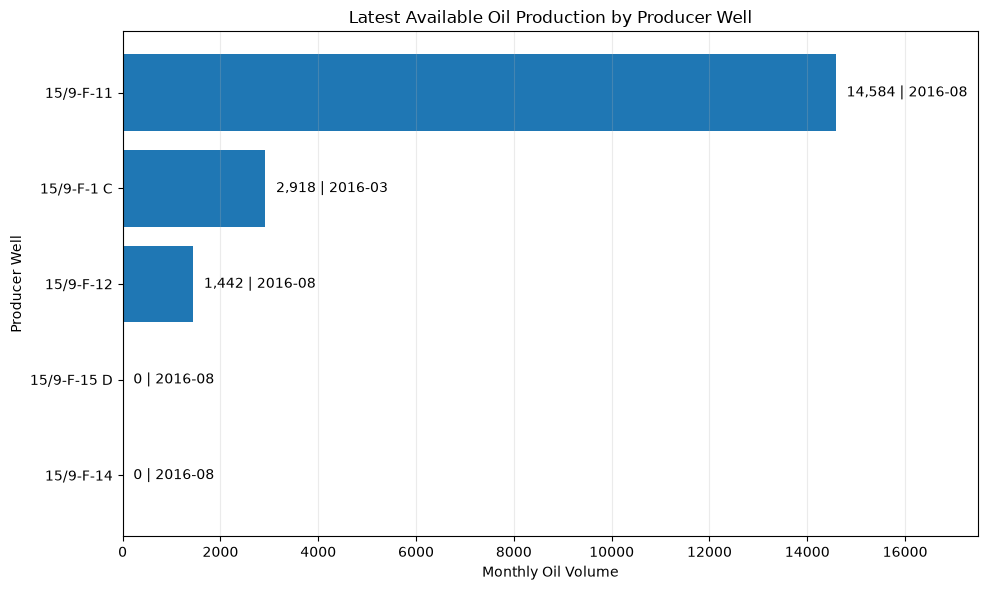

Saved: F:\DataScience_Projects\Volve_Oil_Production\outputs\04_operational_insights\figure_4_1_latest_producer_well_oil_volume.png


In [41]:
latest_plot_df = (
    dashboard_well_summary[
        [
            "NPD_WELL_BORE_NAME",
            "DATE",
            "oil_volume"
        ]
    ]
    .sort_values(
        "oil_volume",
        ascending=True
    )
    .copy()
)


fig, ax = plt.subplots(
    figsize=(10, 6)
)


bars = ax.barh(
    latest_plot_df[
        "NPD_WELL_BORE_NAME"
    ],
    latest_plot_df[
        "oil_volume"
    ]
)


ax.set_title(
    "Latest Available Oil Production by Producer Well"
)

ax.set_xlabel(
    "Monthly Oil Volume"
)

ax.set_ylabel(
    "Producer Well"
)


maximum_oil = (
    latest_plot_df[
        "oil_volume"
    ]
    .max()
)


annotation_padding = (
    maximum_oil
    *
    0.015
)


ax.set_xlim(
    0,
    maximum_oil
    *
    1.20
)


for bar, (_, row) in zip(
    bars,
    latest_plot_df.iterrows()
):
    ax.text(
        bar.get_width()
        +
        annotation_padding,

        bar.get_y()
        +
        bar.get_height() / 2,

        (
            f"{row['oil_volume']:,.0f}"
            f" | {row['DATE']:%Y-%m}"
        ),

        va="center"
    )


ax.grid(
    axis="x",
    alpha=0.25
)


plt.tight_layout()


LATEST_PRODUCTION_FIGURE_PATH = (
    NOTEBOOK04_OUTPUT_DIR
    /
    "figure_4_1_latest_producer_well_oil_volume.png"
)


plt.savefig(
    LATEST_PRODUCTION_FIGURE_PATH,
    dpi=300,
    bbox_inches="tight"
)


plt.show()


print(
    "Saved:",
    LATEST_PRODUCTION_FIGURE_PATH
)

### 4.4 Forecast Reliability by Producer Well

Final-holdout Weighted Absolute Percentage Error (WAPE) is compared between naive persistence and Ridge Regression for each core producer well.

The comparison provides a well-level view of forecasting reliability while preserving the frozen final-holdout results from Notebook 03.

Lower WAPE indicates lower aggregate absolute forecasting error relative to observed oil production. The figure is used for comparative monitoring rather than as an engineering performance threshold.

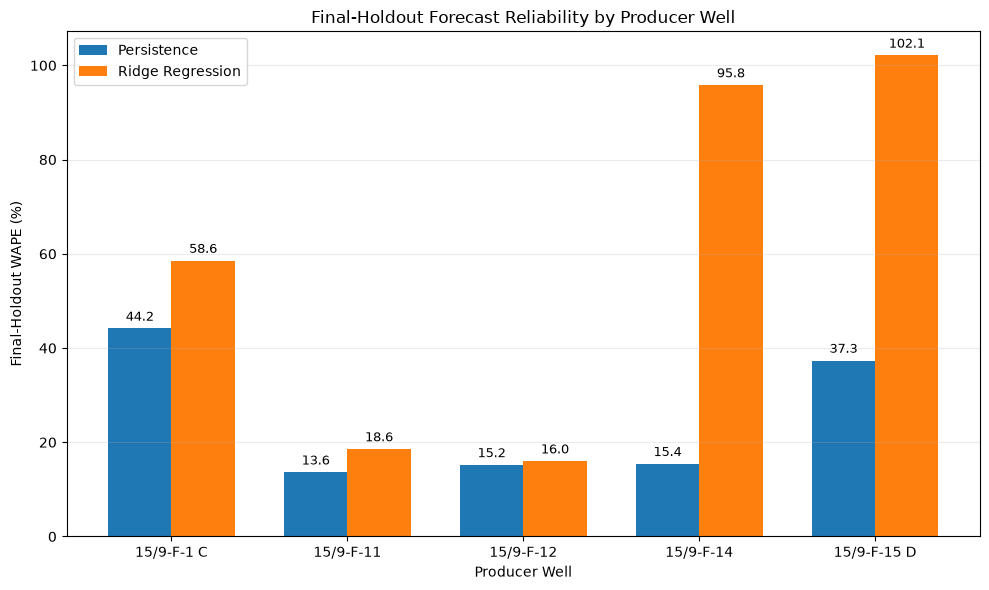

Saved: F:\DataScience_Projects\Volve_Oil_Production\outputs\04_operational_insights\figure_4_2_forecast_reliability_by_well.png


In [42]:
reliability_plot_df = (
    dashboard_well_summary[
        [
            "NPD_WELL_BORE_NAME",
            "persistence_WAPE_pct",
            "ridge_WAPE_pct"
        ]
    ]
    .copy()
)


x_positions = np.arange(
    len(
        reliability_plot_df
    )
)


bar_width = 0.36


fig, ax = plt.subplots(
    figsize=(10, 6)
)


persistence_bars = ax.bar(
    x_positions
    -
    bar_width / 2,

    reliability_plot_df[
        "persistence_WAPE_pct"
    ],

    width=bar_width,

    label="Persistence"
)


ridge_bars = ax.bar(
    x_positions
    +
    bar_width / 2,

    reliability_plot_df[
        "ridge_WAPE_pct"
    ],

    width=bar_width,

    label="Ridge Regression"
)


ax.set_xticks(
    x_positions
)


ax.set_xticklabels(
    reliability_plot_df[
        "NPD_WELL_BORE_NAME"
    ]
)


ax.set_ylabel(
    "Final-Holdout WAPE (%)"
)


ax.set_xlabel(
    "Producer Well"
)


ax.set_title(
    "Final-Holdout Forecast Reliability by Producer Well"
)


ax.legend()


ax.grid(
    axis="y",
    alpha=0.25
)


for bars in [
    persistence_bars,
    ridge_bars
]:
    for bar in bars:
        ax.text(
            bar.get_x()
            +
            bar.get_width() / 2,

            bar.get_height()
            +
            1,

            f"{bar.get_height():.1f}",

            ha="center",
            va="bottom",
            fontsize=9
        )


plt.tight_layout()


FORECAST_RELIABILITY_FIGURE_PATH = (
    NOTEBOOK04_OUTPUT_DIR
    /
    "figure_4_2_forecast_reliability_by_well.png"
)


plt.savefig(
    FORECAST_RELIABILITY_FIGURE_PATH,
    dpi=300,
    bbox_inches="tight"
)


plt.show()


print(
    "Saved:",
    FORECAST_RELIABILITY_FIGURE_PATH
)

### 4.5 Physical Forecast Reliability Diagnostic

The frequency of physically implausible negative Ridge Regression forecasts is compared across the five core producer wells.

The percentage represents the proportion of each well's final-holdout observations for which Ridge Regression predicted an oil volume below zero.

The indicator is retained as a model-reliability diagnostic. It is not an operational alarm threshold and does not modify or clip the original forecasts.

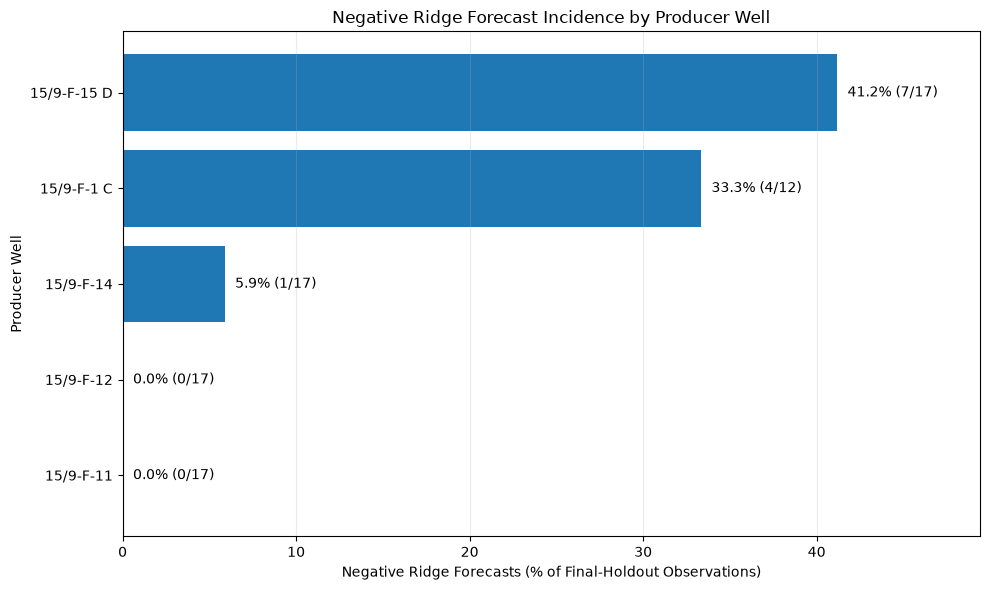

Saved: F:\DataScience_Projects\Volve_Oil_Production\outputs\04_operational_insights\figure_4_3_negative_ridge_forecast_incidence.png


In [43]:
negative_incidence_plot_df = (
    well_negative_incidence
    .sort_values(
        "negative_ridge_forecast_pct",
        ascending=True
    )
    .copy()
)


fig, ax = plt.subplots(
    figsize=(10, 6)
)


bars = ax.barh(
    negative_incidence_plot_df[
        "NPD_WELL_BORE_NAME"
    ],
    negative_incidence_plot_df[
        "negative_ridge_forecast_pct"
    ]
)


ax.set_title(
    "Negative Ridge Forecast Incidence by Producer Well"
)


ax.set_xlabel(
    "Negative Ridge Forecasts (% of Final-Holdout Observations)"
)


ax.set_ylabel(
    "Producer Well"
)


maximum_percentage = (
    negative_incidence_plot_df[
        "negative_ridge_forecast_pct"
    ]
    .max()
)


ax.set_xlim(
    0,
    maximum_percentage
    *
    1.20
)


for bar, (_, row) in zip(
    bars,
    negative_incidence_plot_df.iterrows()
):
    ax.text(
        bar.get_width()
        +
        0.6,

        bar.get_y()
        +
        bar.get_height() / 2,

        (
            f"{row['negative_ridge_forecast_pct']:.1f}%"
            f" ({int(row['negative_ridge_forecasts'])}"
            f"/{int(row['holdout_observations'])})"
        ),

        va="center"
    )


ax.grid(
    axis="x",
    alpha=0.25
)


plt.tight_layout()


NEGATIVE_FORECAST_FIGURE_PATH = (
    NOTEBOOK04_OUTPUT_DIR
    /
    "figure_4_3_negative_ridge_forecast_incidence.png"
)


plt.savefig(
    NEGATIVE_FORECAST_FIGURE_PATH,
    dpi=300,
    bbox_inches="tight"
)


plt.show()


print(
    "Saved:",
    NEGATIVE_FORECAST_FIGURE_PATH
)

### 4.6 Dashboard Forecast-Reliability Summary

A compact forecasting-reliability table is extracted from the integrated monitoring dataset.

The table combines final-holdout WAPE, the Ridge penalty relative to persistence, and the incidence of physically negative Ridge forecasts. These indicators are presented separately rather than combined into a single reliability score.

In [44]:
dashboard_forecast_reliability = (
    dashboard_well_summary[
        [
            "NPD_WELL_BORE_NAME",
            "persistence_WAPE_pct",
            "ridge_WAPE_pct",
            "ridge_minus_persistence_WAPE_points",
            "negative_ridge_forecasts",
            "negative_ridge_forecast_pct"
        ]
    ]
    .copy()
    .sort_values(
        "NPD_WELL_BORE_NAME"
    )
    .reset_index(
        drop=True
    )
)


display(
    dashboard_forecast_reliability.round({
        "persistence_WAPE_pct": 2,
        "ridge_WAPE_pct": 2,
        "ridge_minus_persistence_WAPE_points": 2,
        "negative_ridge_forecast_pct": 2
    })
)

,NPD_WELL_BORE_NAME,persistence_WAPE_pct,ridge_WAPE_pct,ridge_minus_persistence_WAPE_points,negative_ridge_forecasts,negative_ridge_forecast_pct
0,15/9-F-1 C,44.16,58.56,14.39,4,33.33
1,15/9-F-11,13.63,18.57,4.93,0,0.00
2,15/9-F-12,15.20,15.99,0.79,0,0.00
3,15/9-F-14,15.43,95.82,80.39,1,5.88
4,15/9-F-15 D,37.35,102.12,64.78,7,41.18


### 4.7 Latest Production Versus Recent Production Context

The latest available oil production for each core producer well is compared with its recent three-observation mean.

The comparison provides context for whether the latest observed production level is above, close to, or below its immediately preceding production history.

The values are descriptive monitoring indicators only. No operational threshold is imposed, and differences in the latest available observation date between wells are preserved.

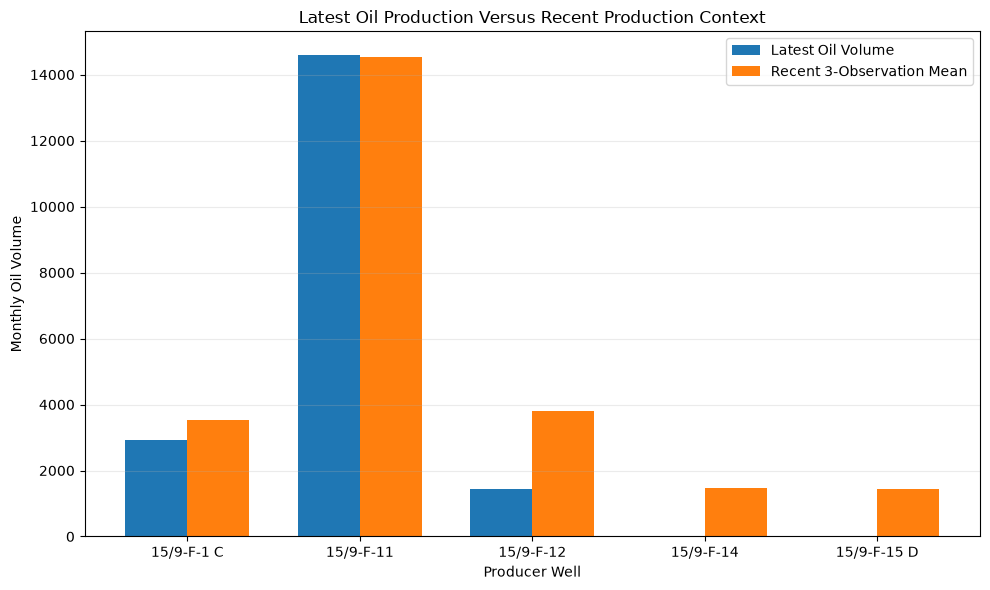

Saved: F:\DataScience_Projects\Volve_Oil_Production\outputs\04_operational_insights\figure_4_4_latest_vs_recent_oil_production.png


In [45]:
production_context_plot_df = (
    dashboard_well_summary[
        [
            "NPD_WELL_BORE_NAME",
            "DATE",
            "oil_volume",
            "recent_3_observation_mean_oil"
        ]
    ]
    .copy()
)


x_positions = np.arange(
    len(
        production_context_plot_df
    )
)


bar_width = 0.36


fig, ax = plt.subplots(
    figsize=(10, 6)
)


latest_bars = ax.bar(
    x_positions
    -
    bar_width / 2,

    production_context_plot_df[
        "oil_volume"
    ],

    width=bar_width,

    label="Latest Oil Volume"
)


recent_mean_bars = ax.bar(
    x_positions
    +
    bar_width / 2,

    production_context_plot_df[
        "recent_3_observation_mean_oil"
    ],

    width=bar_width,

    label="Recent 3-Observation Mean"
)


ax.set_xticks(
    x_positions
)


ax.set_xticklabels(
    production_context_plot_df[
        "NPD_WELL_BORE_NAME"
    ]
)


ax.set_ylabel(
    "Monthly Oil Volume"
)


ax.set_xlabel(
    "Producer Well"
)


ax.set_title(
    "Latest Oil Production Versus Recent Production Context"
)


ax.legend()


ax.grid(
    axis="y",
    alpha=0.25
)


plt.tight_layout()


PRODUCTION_CONTEXT_FIGURE_PATH = (
    NOTEBOOK04_OUTPUT_DIR
    /
    "figure_4_4_latest_vs_recent_oil_production.png"
)


plt.savefig(
    PRODUCTION_CONTEXT_FIGURE_PATH,
    dpi=300,
    bbox_inches="tight"
)


plt.show()


print(
    "Saved:",
    PRODUCTION_CONTEXT_FIGURE_PATH
)

### 4.8 Dashboard Production-Monitoring Summary

A compact production-monitoring table is assembled using the latest available production state, recent production direction, recent zero-production context, water-cut availability, and operating time.

The table keeps physical production condition separate from forecasting reliability so that model behaviour is not interpreted as an engineering diagnosis.

In [46]:
dashboard_production_monitoring = (
    dashboard_well_summary[
        [
            "NPD_WELL_BORE_NAME",
            "DATE",
            "oil_volume",
            "oil_volume_change_pct",
            "recent_3_observation_mean_oil",
            "recent_3_zero_observations",
            "on_stream_hours",
            "water_cut_pct",
            "latest_production_state",
            "recent_direction",
            "ratio_measurement_state"
        ]
    ]
    .copy()
    .sort_values(
        "NPD_WELL_BORE_NAME"
    )
    .reset_index(
        drop=True
    )
)


display(
    dashboard_production_monitoring.round({
        "oil_volume": 2,
        "oil_volume_change_pct": 2,
        "recent_3_observation_mean_oil": 2,
        "on_stream_hours": 2,
        "water_cut_pct": 2
    })
)

,NPD_WELL_BORE_NAME,DATE,oil_volume,oil_volume_change_pct,recent_3_observation_mean_oil,recent_3_zero_observations,on_stream_hours,water_cut_pct,latest_production_state,recent_direction,ratio_measurement_state
0,15/9-F-1 C,2016-03-01,2917.50,-38.16,3538.99,0,356.76,82.13,Positive production at latest origin,Decline from previous month,Current ratio indicators available
1,15/9-F-11,2016-08-01,14583.73,1.38,14519.74,0,743.67,85.75,Positive production at latest origin,Increase from previous month,Current ratio indicators available
2,15/9-F-12,2016-08-01,1442.03,-68.19,3794.72,0,285.89,88.35,Positive production at latest origin,Decline from previous month,Current ratio indicators available
3,15/9-F-14,2016-08-01,0.00,-100.00,1467.30,1,0.00,NaN,Zero production at latest origin,Decline from previous month,Current ratio indicators unavailable
4,15/9-F-15 D,2016-08-01,0.00,-100.00,1430.83,1,0.00,NaN,Zero production at latest origin,Decline from previous month,Current ratio indicators unavailable


### 4.9 Latest Month-to-Month Production Change

The latest month-to-month change in oil production is compared across the five core producer wells.

The percentage change provides a concise view of recent production direction at each well's latest available monitoring origin.

The values are descriptive observations rather than engineering decline thresholds. A negative percentage indicates lower production than the preceding observation, while a positive percentage indicates an increase.

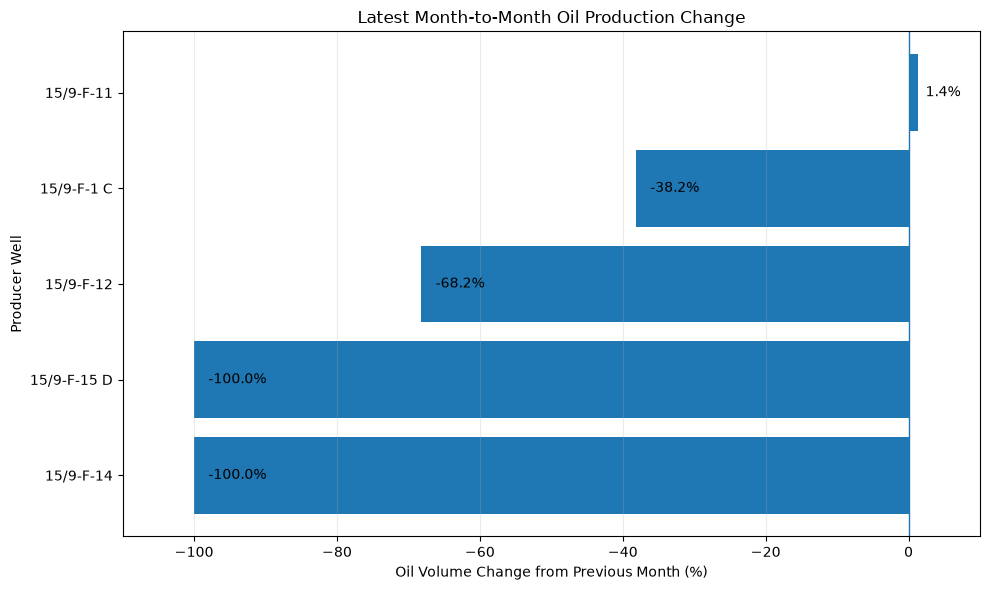

Saved: F:\DataScience_Projects\Volve_Oil_Production\outputs\04_operational_insights\figure_4_5_latest_oil_production_change.png


In [47]:
production_change_plot_df = (
    dashboard_well_summary[
        [
            "NPD_WELL_BORE_NAME",
            "DATE",
            "oil_volume_change_pct"
        ]
    ]
    .sort_values(
        "oil_volume_change_pct",
        ascending=True
    )
    .copy()
)


fig, ax = plt.subplots(
    figsize=(10, 6)
)


bars = ax.barh(
    production_change_plot_df[
        "NPD_WELL_BORE_NAME"
    ],
    production_change_plot_df[
        "oil_volume_change_pct"
    ]
)


ax.axvline(
    0,
    linewidth=1
)


ax.set_title(
    "Latest Month-to-Month Oil Production Change"
)


ax.set_xlabel(
    "Oil Volume Change from Previous Month (%)"
)


ax.set_ylabel(
    "Producer Well"
)


# Keep enough space on both sides of the bars
ax.set_xlim(
    -110,
    10
)


# Add percentage labels without allowing the -100% labels
# to collide with the y-axis labels.
for bar, (_, row) in zip(
    bars,
    production_change_plot_df.iterrows()
):
    value = row[
        "oil_volume_change_pct"
    ]

    label_x = (
        value + 2
        if value < 0
        else value + 1
    )

    ax.text(
        label_x,

        bar.get_y()
        +
        bar.get_height() / 2,

        f"{value:.1f}%",

        va="center",
        ha="left"
    )


ax.grid(
    axis="x",
    alpha=0.25
)


plt.tight_layout()


PRODUCTION_CHANGE_FIGURE_PATH = (
    NOTEBOOK04_OUTPUT_DIR
    /
    "figure_4_5_latest_oil_production_change.png"
)


plt.savefig(
    PRODUCTION_CHANGE_FIGURE_PATH,
    dpi=300,
    bbox_inches="tight"
)


plt.show()


print(
    "Saved:",
    PRODUCTION_CHANGE_FIGURE_PATH
)

### 4.10 Export of Dashboard Component Tables

The production-monitoring and forecast-reliability tables are exported as separate CSV files.

These files provide simplified inputs for later dashboard development while preserving the more comprehensive integrated well-summary dataset exported earlier.

In [48]:
PRODUCTION_MONITORING_PATH = (
    NOTEBOOK04_OUTPUT_DIR
    /
    "dashboard_production_monitoring.csv"
)


FORECAST_RELIABILITY_PATH = (
    NOTEBOOK04_OUTPUT_DIR
    /
    "dashboard_forecast_reliability.csv"
)


dashboard_production_monitoring.to_csv(
    PRODUCTION_MONITORING_PATH,
    index=False
)


dashboard_forecast_reliability.to_csv(
    FORECAST_RELIABILITY_PATH,
    index=False
)


assert (
    PRODUCTION_MONITORING_PATH.exists()
)


assert (
    FORECAST_RELIABILITY_PATH.exists()
)


print(
    "Saved:",
    PRODUCTION_MONITORING_PATH
)


print(
    "Saved:",
    FORECAST_RELIABILITY_PATH
)


print(
    "\nPASS: dashboard component tables exported successfully."
)

Saved: F:\DataScience_Projects\Volve_Oil_Production\outputs\04_operational_insights\dashboard_production_monitoring.csv
Saved: F:\DataScience_Projects\Volve_Oil_Production\outputs\04_operational_insights\dashboard_forecast_reliability.csv

PASS: dashboard component tables exported successfully.


### 4.11 Final Notebook 04 Artifact Verification

The analytical outputs generated by this notebook are verified before the operational-insight workflow is closed.

The verification confirms that the three dashboard-ready datasets and five monitoring figures required from Notebook 04 have been successfully created.

This step checks artifact availability only. It does not alter any analytical results or forecasting outputs.

In [49]:
required_notebook04_artifacts = {
    "Integrated dashboard well summary":
        NOTEBOOK04_OUTPUT_DIR
        /
        "dashboard_well_summary.csv",

    "Production monitoring dashboard table":
        NOTEBOOK04_OUTPUT_DIR
        /
        "dashboard_production_monitoring.csv",

    "Forecast reliability dashboard table":
        NOTEBOOK04_OUTPUT_DIR
        /
        "dashboard_forecast_reliability.csv",

    "Figure 4.1 - Latest producer-well oil volume":
        NOTEBOOK04_OUTPUT_DIR
        /
        "figure_4_1_latest_producer_well_oil_volume.png",

    "Figure 4.2 - Forecast reliability by well":
        NOTEBOOK04_OUTPUT_DIR
        /
        "figure_4_2_forecast_reliability_by_well.png",

    "Figure 4.3 - Negative Ridge forecast incidence":
        NOTEBOOK04_OUTPUT_DIR
        /
        "figure_4_3_negative_ridge_forecast_incidence.png",

    "Figure 4.4 - Latest versus recent oil production":
        NOTEBOOK04_OUTPUT_DIR
        /
        "figure_4_4_latest_vs_recent_oil_production.png",

    "Figure 4.5 - Latest oil production change":
        NOTEBOOK04_OUTPUT_DIR
        /
        "figure_4_5_latest_oil_production_change.png"
}


artifact_verification = pd.DataFrame(
    [
        {
            "artifact": artifact_name,
            "path": str(artifact_path),
            "exists": artifact_path.exists(),
            "size_bytes": (
                artifact_path.stat().st_size
                if artifact_path.exists()
                else np.nan
            )
        }
        for artifact_name, artifact_path
        in required_notebook04_artifacts.items()
    ]
)


display(
    artifact_verification
)


assert (
    artifact_verification[
        "exists"
    ]
    .all()
)


assert (
    len(
        artifact_verification
    )
    ==
    8
)


print(
    "Verified artifacts:",
    int(
        artifact_verification[
            "exists"
        ]
        .sum()
    ),
    "/",
    len(
        artifact_verification
    )
)


print(
    "PASS: all required Notebook 04 artifacts exist."
)

,artifact,path,exists,size_bytes
0,Integrated dashboard well summary,F:\DataScience_Projects\Volve_Oil_Production\o...,True,1711
1,Production monitoring dashboard table,F:\DataScience_Projects\Volve_Oil_Production\o...,True,1102
2,Forecast reliability dashboard table,F:\DataScience_Projects\Volve_Oil_Production\o...,True,552
3,Figure 4.1 - Latest producer-well oil volume,F:\DataScience_Projects\Volve_Oil_Production\o...,True,129290
4,Figure 4.2 - Forecast reliability by well,F:\DataScience_Projects\Volve_Oil_Production\o...,True,129877
5,Figure 4.3 - Negative Ridge forecast incidence,F:\DataScience_Projects\Volve_Oil_Production\o...,True,134637
6,Figure 4.4 - Latest versus recent oil production,F:\DataScience_Projects\Volve_Oil_Production\o...,True,119669
7,Figure 4.5 - Latest oil production change,F:\DataScience_Projects\Volve_Oil_Production\o...,True,119185


Verified artifacts: 8 / 8
PASS: all required Notebook 04 artifacts exist.


### 4.12 Final Operational Interpretation

The operational monitoring analysis combines recent producer-well condition with the frozen forecasting evidence from Notebook 03.

The latest available production observations show substantially different well states. F-11 remained close to its recent three-observation production level and recorded a small month-to-month increase. F-1 C and F-12 showed lower latest production relative to their recent production history, while F-14 and F-15 D had reached zero production at their latest monitoring origins. The missing ratio indicators for F-14 and F-15 D are retained as unavailable because they coincide with zero production and zero on-stream time rather than representing ordinary missing measurements.

Forecast reliability also differed considerably between wells. Naive persistence produced lower final-holdout WAPE than the selected Ridge Regression model for all five core producer wells. The difference was relatively small for F-12 and F-11 but much larger for F-14 and F-15 D. This reinforces the importance of evaluating predictive models against a simple temporal benchmark rather than assuming that a trained machine-learning model will necessarily provide superior short-horizon forecasts.

The diagnostic analysis identified 12 physically implausible negative Ridge forecasts. All occurred within the lower half of forecasting-origin oil production, with most concentrated in F-1 C and F-15 D. However, lower production alone did not fully explain the behaviour because other wells also contained lower-production observations without negative forecasts. In addition, the two sustained zero-production observations produced a different failure pattern in which persistence predicted zero exactly while Ridge produced large positive forecasts. These findings indicate multiple forms of reduced Ridge reliability in the late-production conditions represented by the final holdout.

The results do not establish engineering causes for production decline or forecasting error. Water cut, gas-oil ratio, production age, operating time, recent production history, and well identity provide useful descriptive context, but no individual variable was demonstrated to independently explain the observed forecasting failures.

From an operational decision-support perspective, the analysis therefore supports monitoring production condition and forecasting reliability as separate but complementary information streams. Recent oil production, production direction, operating time, ratio availability, persistence error, Ridge error, and physically invalid forecast incidence can be presented together in a dashboard without converting them into unsupported alarm thresholds or automated engineering recommendations.

Overall, Notebook 04 translates the exploratory, decline-analysis, and predictive-model results into reproducible producer-well monitoring outputs while preserving the limitations identified during validation. The resulting dashboard-ready datasets and figures provide a practical foundation for the application layer of the Volve Oil Production Data Science Project.
